# 3. Forced response: calculations

For each single-forcing experiment, what has changed relative to hist-nat (natural forcing only), and is it more than natural variability can produce? This notebook does the calculations and saves every result; notebook 04 draws the figures from the saved results.

| Section | What it computes | Saved as (`results/<variable>/<run>/...`) |
|---|---|---|
| 1. Quantile change | rolling quantiles of every experiment, smoothed, and hist-nat's whole-record quantiles | `q_histnat_base`, `rolling_quantiles`, `smooth_quantiles` |
| 2. Change in width | the change in Q95 − Q05 and its hist-nat bootstrap test | `qrange_change` |
| 3. Quantile response | the change in Q05, Q50, Q95 (and every 5th percentile, Antarctic mean) | `quantile_response`, `quantile_curve` |
| 4. Mean change | Welch t-test and member-block permutation test | `ttest`, `mean_block` |
| 5. Signal to noise | S/N of each experiment against hist-nat | `signal`, `noise`, `sn` |
| 6. Additivity | each experiment's change from its own 1850–1900 baseline | `own_changes` |
| 7. Mean and variability | the inputs to the combined figures | `mean_response`, `tails` |
| 8. Zonal means | tests of the zonal-mean change in the mean and in the width | `zonal_mean_test`, `zonal_width_test` |

Every section starts with how its method works, shown at one grid point, before running it everywhere.

**Following the data.** Every step prints what it made. Before each method figure comes a **quick look**: the arrays the figure is given, picked out and printed, then drawn plainly with xarray's own `.plot`, all of the code here in the notebook. The method figure after it is given exactly those arrays. Names end in their type: `_tree` (DataTree), `_ds` (Dataset), `_da` (DataArray), `_arr` (numpy array), `_df` (DataFrame).

**Notation.** $x_{m,y}$ is one season's mean in member $m$ and year $y$, at one grid point; an ensemble has $M$ members. $Q_p(\cdot)$ is the $p$ quantile of a set of values. "The final years" are the last $L = 21$ years of the record (`config.WINDOW`): 1993–2013.

## Setup

In [1]:
import sys
sys.path[:0] = ['..', '../../extant-functions']   # this repository (the extant package) and plotting_modules

import logging
import warnings
from importlib import reload

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

from dask.distributed import wait
from plotting_modules import formatting, maps
from extant import config, loading, paths, preprocessing as pp, storage
from extant.logger import setup_logging
from extant.plots import methods

logger = setup_logging('extant', logging.INFO)
xr.set_options(display_expand_attrs=False, display_expand_data=False)

#(t): Dask warns about every large task graph; the graphs here are large on purpose
warnings.filterwarnings('ignore', message='.*Sending large graph of size.*', category=UserWarning)

from functools import partial

from plotting_modules.constants import FORCING_COLORS
from extant import datatree, quantiles as qc, response_change as rc, significance as sig, zonal
from extant.plots import zonal as zp

## Settings

In [2]:
VARIABLE = 'tas'
var = config.VARIABLES[VARIABLE]

WINDOW = config.WINDOW
QUANTILES = config.QUANTILES

#(t): The quantile pair whose width (Q95 - Q05) is tested, and the significance level
QRANGE_QUANTILES = (0.05, 0.95)
ALPHA = 0.05

#(t): One experiment at one grid point, for the method figures
DEMO_MODEL = config.PLOT_SEL['model']
DEMO_EXPERIMENT = config.PLOT_SEL['experiment']
DEMO_POINT = {'season': 'DJF', 'lat': -75.0, 'lon': -180.0}


def result_path(name):
    """Where a result of this notebook is saved: results/<variable>/<run>/<name>.zarr."""
    return paths.result(name, VARIABLE, RUN)

## Dask cluster (JASMIN)

The heavy steps run on a Dask Gateway cluster on JASMIN. `jasmin.stop_all(gateway)` stops every cluster left over from an earlier kernel.

In [3]:
#(t): Start a Dask Gateway cluster, or reuse the one already running, and send it the extant package
#(c): Re-run upload_package after editing anything in extant/: the workers run its functions
from extant import jasmin

gateway, cluster, client = jasmin.connect(n_workers=20, wait_for=6)
jasmin.upload_package(client)
client

Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: /_jasmin/proxy/dask-gateway/clusters/ea69064d46fc454da4dd64bd14bc8091/status,


## Open the data

Run **one** of the next two sections. Both leave `lesfmip_season_tree` (seasonal means as a DataTree, `/<model>/<experiment>`, on member × year × season × lat × lon, in analysis units) and `RUN`.

### Sample data

The 3×3 block of grid cells around `config.POINT` in `tests/data`, through the same pre-processing as notebook 01.

In [4]:
lesfmip_season_tree = pp.seasonal_tree(loading.open_lesfmip_sample(experiments=config.MAIN_EXPERIMENTS), VARIABLE).compute()
RUN = 'sample'

13:33:32 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-GHG_sample.nc as /CanESM5/hist-GHG
13:33:34 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-aer_sample.nc as /CanESM5/hist-aer
13:33:34 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-nat_sample.nc as /CanESM5/hist-nat
13:33:34 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_hist-totalO3_sample.nc as /CanESM5/hist-totalO3
13:33:34 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/CanESM5_historical_sample.nc as /CanESM5/historical
13:33:34 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/HadGEM3-GC31-LL_hist-GHG_sample.nc as /HadGEM3-GC31-LL/hist-GHG
13:33:34 INFO    extant.loading | opening /home/users/aborow/ExtAnt-initial/tests/data/HadGEM3-GC31-LL_hist-aer_sample.nc as /HadGEM3-GC31-LL/hist-aer
13:33:34 IN

### Full data (JASMIN)

The seasonal means notebook 01 saved (section 3) as `seasonal/lesfmip_<variable>.zarr`. That store is read from `paths.DATA_DIR` (the group workspace) if it has been moved there, and otherwise from `paths.SCRATCH`, where notebook 01 writes it. The first cell shows both places and whether the store is there.

In [ ]:
#(t): The two places the seasonal store can be: DATA_DIR is read first, then SCRATCH
seasonal_store = paths.seasonal('lesfmip', VARIABLE)
for root in (paths.DATA_DIR, paths.SCRATCH):
    print(f'{"found  " if (root / seasonal_store).exists() else "missing"} {root / seasonal_store}')

In [ ]:
seasonal_path = paths.find(seasonal_store)
print(f'reading {seasonal_path}')
lesfmip_season_tree = xr.open_datatree(seasonal_path, engine='zarr', chunks={})

#(t): Only the experiments analysed (filter keeps the model nodes above them)
lesfmip_season_tree = lesfmip_season_tree.filter(lambda node: node.name in config.MAIN_EXPERIMENTS)
lesfmip_season_tree = lesfmip_season_tree.persist()
wait(lesfmip_season_tree)
RUN = 'full'

### What was opened

Whichever section ran: every model and experiment in `lesfmip_season_tree`, then one of its nodes in full.

In [ ]:
#(t): Every model and experiment: its members, years, seasons and grid
pd.DataFrame({
    node.path: {'members': node.sizes['member'], 'years': f'{int(node.year[0])}-{int(node.year[-1])}',
                'seasons': ', '.join(node.season.values), 'lat x lon': f"{node.sizes['lat']} x {node.sizes['lon']}"}
    for node in lesfmip_season_tree.leaves
}).T

In [ ]:
#(t): One node in full: a Dataset on (member, lat, lon, year, season)
print(f'results are saved under {paths.SCRATCH / "results" / VARIABLE / RUN}')
lesfmip_season_tree[DEMO_MODEL][DEMO_EXPERIMENT].to_dataset()

## A first look

Every member of each experiment at the demonstration point, for one model. hist-nat (green) has only natural forcing (solar and volcanic), so its spread is what the climate does on its own; every other experiment is compared with it.

First the two ensembles every method figure below starts from: one season at the demonstration point, `DEMO_EXPERIMENT` and hist-nat, each on (member, year).

In [5]:
#(t): One model at the demonstration point, every experiment and season, loaded into memory
demo_tree = lesfmip_season_tree[DEMO_MODEL].sel(lat=DEMO_POINT['lat'], lon=DEMO_POINT['lon'], method='nearest').load()

#(t): The two ensembles every method figure below starts from: one season, on (member, year)
demo_experiment_da = demo_tree[DEMO_EXPERIMENT][VARIABLE].sel(season=DEMO_POINT['season'])
demo_histnat_da = demo_tree['hist-nat'][VARIABLE].sel(season=DEMO_POINT['season'])
print(demo_experiment_da, '\n')
print(demo_histnat_da)

<xarray.DataArray 'tas' (member: 65, year: 164)> Size: 43kB
-34.3 -35.37 -33.82 -34.07 -33.67 -33.1 ... -31.91 -33.59 -31.48 -31.88 -31.63
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
    season   <U3 12B 'DJF'
    lon      float64 8B 117.5
  * member   (member) <U9 2kB 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p1f1' 'r9i1p2f1'
    lat      float64 8B -80.0 

<xarray.DataArray 'tas' (member: 50, year: 164)> Size: 33kB
-35.08 -32.54 -35.28 -32.74 -34.63 -32.89 ... -34.77 -33.55 -34.98 -33.18 -35.14
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
    season   <U3 12B 'DJF'
    lon      float64 8B 117.5
  * member   (member) <U9 2kB 'r10i1p1f1' 'r10i1p2f1' ... 'r9i1p1f1' 'r9i1p2f1'
    lat      float64 8B -80.0


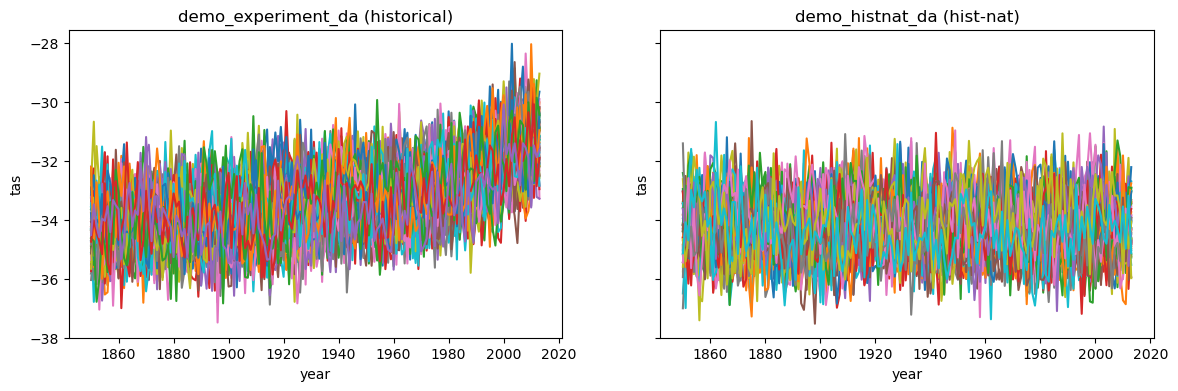

In [6]:
#(t): Quick look: every member of the two, as they are
fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
demo_experiment_da.plot.line(x='year', hue='member', add_legend=False, ax=axes[0])
demo_histnat_da.plot.line(x='year', hue='member', add_legend=False, ax=axes[1])
axes[0].set_title(f'demo_experiment_da ({DEMO_EXPERIMENT})')
axes[1].set_title(f'demo_histnat_da ({'hist-nat'})');

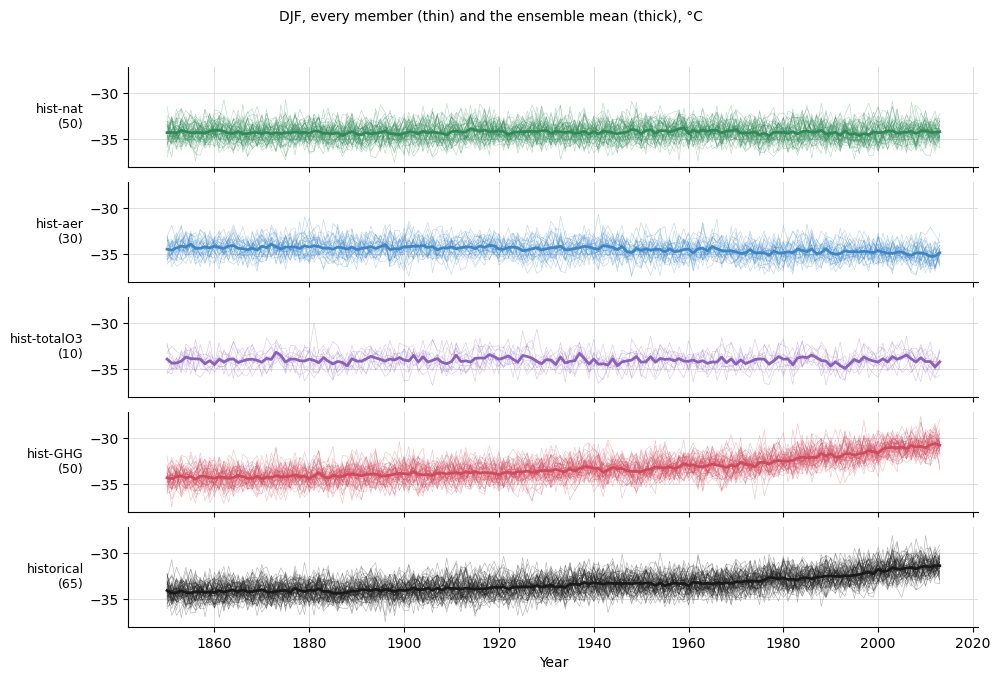

In [7]:
fig, axes = methods.members_by_experiment(demo_tree, config.MAIN_EXPERIMENTS, VARIABLE, season=DEMO_POINT['season'],
                                          units=var.units)

## 1. Quantile change relative to hist-nat

**Rolling quantiles.** For each year $t$, every member's values in the $L$ years centred on $t$ are pooled and their quantiles taken:

$$
Q_p(t) = Q_p\left(\{\,x_{m,y} : m = 1,\ldots,M,\ |y - t| \le \tfrac{L-1}{2}\,\}\right),
$$

so each comes from $M \times L$ values (over a thousand for 50 members). Windows that run off either end of the record are left out.

**Smoothing.** The rolling quantiles are then smoothed with LOWESS (local linear regression, 81-year span), giving $\tilde{Q}_p(t)$.

**The change.** Each experiment's smoothed quantiles minus hist-nat's quantiles over its whole record (members and years pooled):

$$
\Delta Q_p(t) = \tilde{Q}_p^{\,\mathrm{exp}}(t) - Q_p^{\,\mathrm{nat}}.
$$

The change in the width of the distribution between two quantiles is then the difference of their changes. Taking anomalies first gives the same thing:

$$
\Delta W(t) = \Delta Q_{95}(t) - \Delta Q_{05}(t) = \left(\tilde{Q}_{95}^{\,\mathrm{exp}} - \tilde{Q}_{05}^{\,\mathrm{exp}}\right) - \left(Q_{95}^{\,\mathrm{nat}} - Q_{05}^{\,\mathrm{nat}}\right),
$$

which is the same as differencing the widths (as in Bracegirdle et al., 2024).

How one point of a rolling quantile is made, at the demonstration point:

In [8]:
#(t): The rolling quantiles of DEMO_EXPERIMENT at the point: members pooled in each WINDOW-year window, on (quantile, year)
demo_rolling_da = qc.rolling_percentile_xr(demo_experiment_da, window=WINDOW, quantiles=QUANTILES)
print(demo_rolling_da)

<xarray.DataArray 'tas' (quantile: 7, year: 164)> Size: 9kB
nan nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan nan
Coordinates:
  * year      (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
    season    <U3 12B 'DJF'
    lon       float64 8B 117.5
    lat       float64 8B -80.0
  * quantile  (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99


In [9]:
#(t): Check by hand: the window centred on 1960, every member's values pooled, and numpy's quantiles of them
window_arr = demo_experiment_da.sel(year=slice(1960 - WINDOW // 2, 1960 + WINDOW // 2)).values.ravel()
print(f'{window_arr.size} values ({demo_experiment_da.sizes["member"]} members x {WINDOW} years)')
print('np.nanquantile:       ', np.nanquantile(window_arr, QUANTILES).round(3))
print('rolling_percentile_xr:', demo_rolling_da.sel(year=1960).values.round(3))

1365 values (65 members x 21 years)
np.nanquantile:        [-35.466 -34.852 -34.508 -33.31  -32.011 -31.634 -31.065]
rolling_percentile_xr: [-35.466 -34.852 -34.508 -33.31  -32.011 -31.634 -31.065]


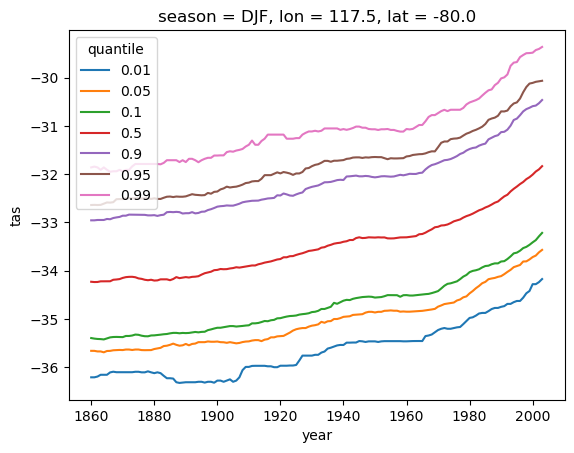

In [10]:
#(t): Quick look: the rolling quantiles, one line per quantile
demo_rolling_da.plot.line(x='year', hue='quantile');

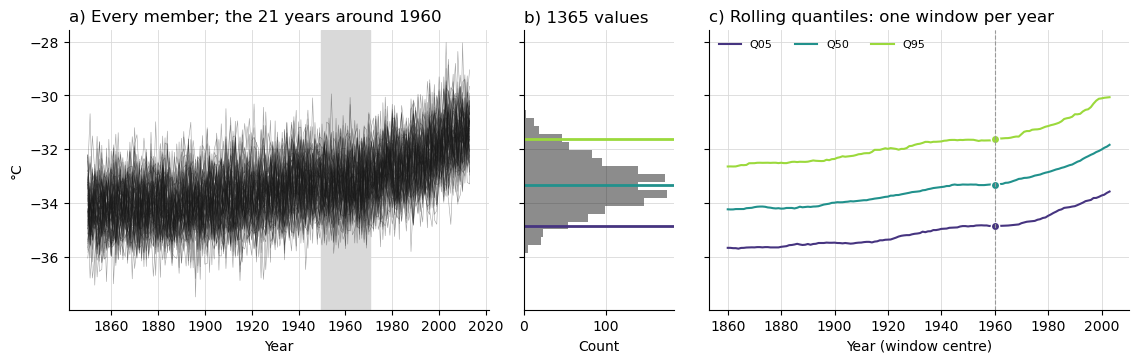

In [11]:
fig, axes = methods.rolling_quantile_demo(demo_experiment_da, demo_rolling_da, year=1960, window=WINDOW,
                                          color=FORCING_COLORS[DEMO_EXPERIMENT], units=var.units)

Now everywhere: hist-nat's whole-record quantiles, and the rolling quantiles of every model and experiment (numba, on the cluster), then smoothed.

In [ ]:
%%time
#(t): hist-nat's quantiles over its whole record, members and years pooled
q_histnat_base_ds = datatree.reduce_to_dataset(
    lesfmip_season_tree.match(f'*/{'hist-nat'}'),
    partial(qc.pooled_quantiles, quantiles=QUANTILES),
).sel(experiment='hist-nat', drop=True).compute()


In [74]:
WINDOW, QUANTILES

(21, array([0.01, 0.05, 0.1 , 0.5 , 0.9 , 0.95, 0.99]))

In [12]:
%%time
#(t): Rolling quantiles pool the members, so every model and experiment shares the same dims: one Dataset
rolling_quantiles_ds = datatree.reduce_to_dataset(
    lesfmip_season_tree,
    partial(qc.rolling_percentile_xr, rolling_dim='year', window=WINDOW, quantiles=QUANTILES, extra_dims=['member']),
).persist()
wait(rolling_quantiles_ds)

smooth_quantiles_ds = qc.lowess_matrix_xarray(rolling_quantiles_ds).compute()

CPU times: user 117 ms, sys: 15.1 ms, total: 132 ms
Wall time: 6.71 s


In [85]:
smooth_quantiles_ds = smooth_quantiles_ds.dropna(dim='year')

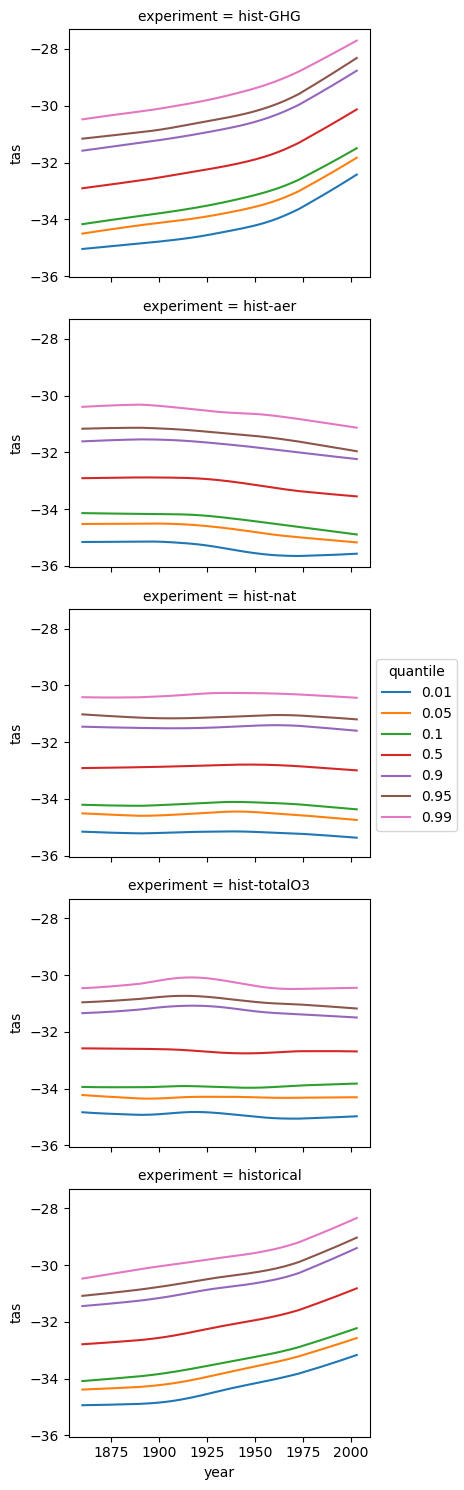

In [86]:
smooth_quantiles_ds.tas.isel(model=0, season=0, lat=0, lon=0).plot(row='experiment', hue='quantile')

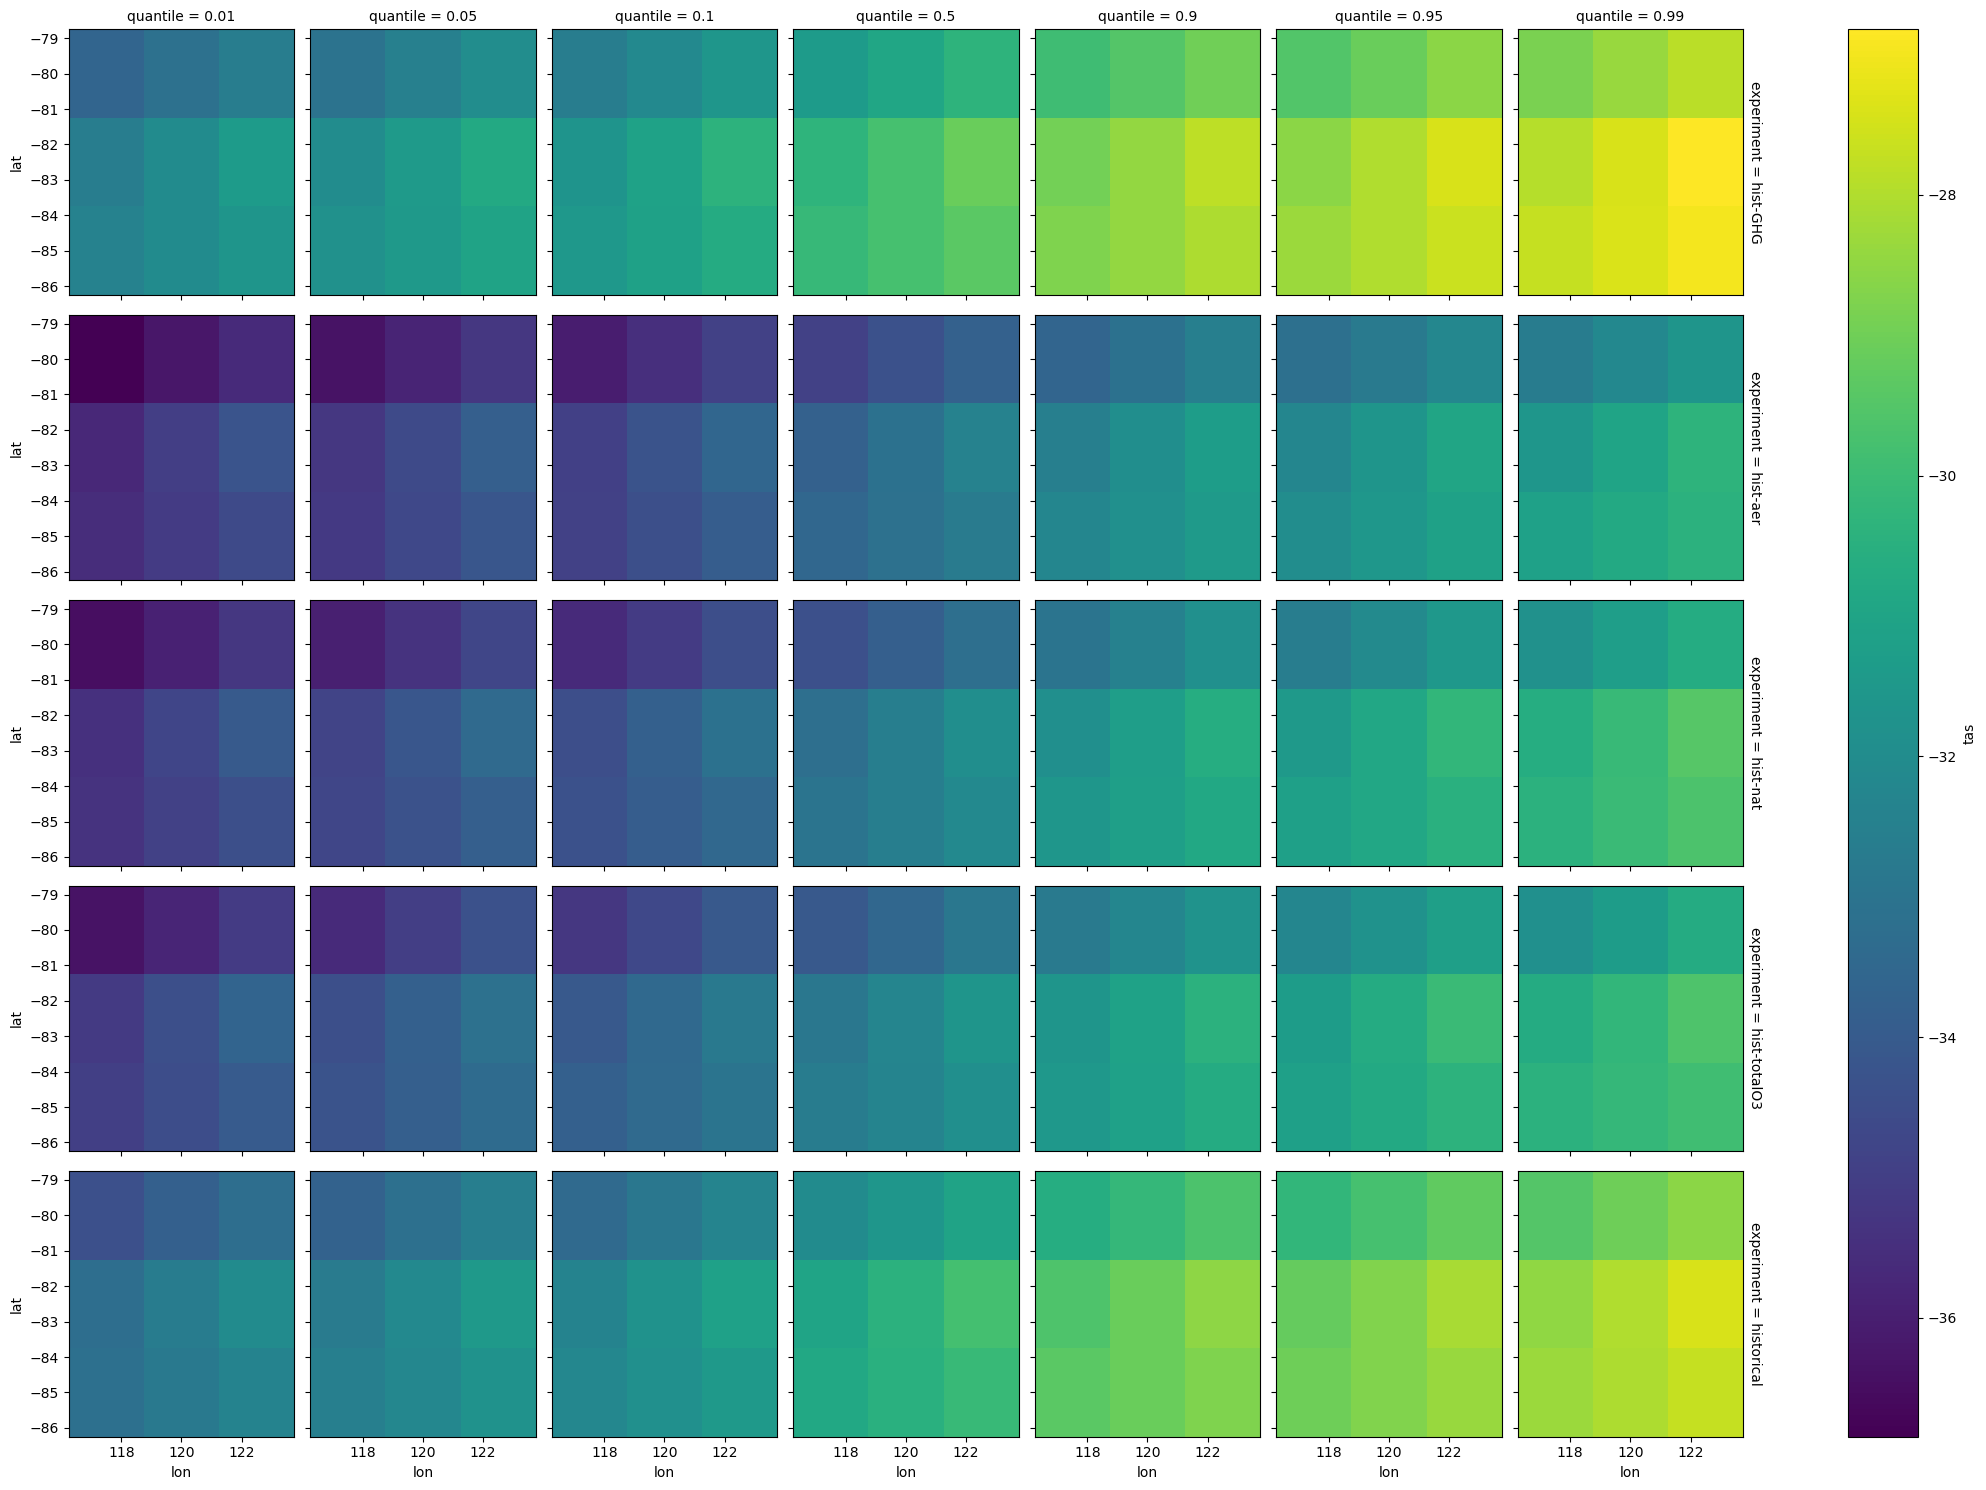

In [87]:
smooth_quantiles_ds.tas.isel(model=0, season=0, year=-1).plot(col='quantile', row='experiment')

In [89]:
q_histnat_base_ds

<xarray.Dataset> Size: 4kB
Dimensions:   (model: 2, lat: 3, lon: 3, season: 4, quantile: 7)
Coordinates:
  * model     (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * season    (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon       (lon) float64 24B 117.5 120.0 122.5
  * lat       (lat) float64 24B -85.0 -82.5 -80.0
  * quantile  (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
Data variables:
    tas       (lat, lon, season, quantile, model) float64 4kB -35.22 ... -42.58

In [90]:
smooth_quantiles_ds

<xarray.Dataset> Size: 3MB
Dimensions:     (lat: 3, lon: 3, season: 4, quantile: 7, model: 2,
                 experiment: 5, year: 144)
Coordinates:
  * model       (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1860 1861 1862 1863 ... 2000 2001 2002 2003
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 24B 117.5 120.0 122.5
  * lat         (lat) float64 24B -85.0 -82.5 -80.0
  * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99
Data variables:
    tas         (lat, lon, season, quantile, model, experiment, year) float64 3MB ...

In [14]:
%%time
storage.save(q_histnat_base_ds, result_path('q_histnat_base'))
storage.save(rolling_quantiles_ds, result_path('rolling_quantiles'))
storage.save(smooth_quantiles_ds, result_path('smooth_quantiles'))

13:33:56 INFO    extant.storage | writing Dataset (model: 2, lat: 3, lon: 3, season: 4, quantile: 7) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/q_histnat_base.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:33:57 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/q_histnat_base.zarr
13:33:57 INFO    extant.storage | writing Dataset (model: 2, experiment: 5, lat: 3, lon: 3, season: 4, quantile: 7, year: 164) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/rolling_quantiles.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:33:58 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/rolling_quantiles.zarr
13:33:58 INFO    extant.storage | writing Dataset (lat: 3, lon: 3, season: 4, quantile: 7, model: 2, experiment: 5, year: 164) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/smooth_quantiles.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:33:59 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/smooth_quantiles.zarr
CPU times: user 180 ms, sys: 102 ms, total: 282 ms
Wall time: 2.82 s


PosixPath('/work/scratch-pw4/aborow/ExtAnt/results/tas/sample/smooth_quantiles.zarr')

The smoothing, and the change against hist-nat, at the demonstration point. First the point is picked out of the three results, printed and plotted plainly; then the two method figures, which are given exactly these arrays: on the left, thin lines are the rolling quantiles and thick the smoothed ones; on the right, $\Delta Q_{05}$ and $\Delta Q_{95}$, with the change in width as the gap between them.

In [15]:
#(t): The demonstration point picked out of the three results
demo_sel = dict(model=DEMO_MODEL, season=DEMO_POINT['season'])
demo_latlon = dict(lat=DEMO_POINT['lat'], lon=DEMO_POINT['lon'], method='nearest')
point_rolling_da = rolling_quantiles_ds[VARIABLE].sel(**demo_sel).sel(**demo_latlon)   # on experiment, quantile, year
point_smooth_da = smooth_quantiles_ds[VARIABLE].sel(**demo_sel).sel(**demo_latlon)     # on experiment, quantile, year
point_base_da = q_histnat_base_ds[VARIABLE].sel(**demo_sel).sel(**demo_latlon)         # on quantile
point_change_da = point_smooth_da - point_base_da                                       # on experiment, quantile, year
print(point_smooth_da, '\n')
print(point_base_da)

<xarray.DataArray 'tas' (quantile: 7, experiment: 5, year: 164)> Size: 46kB
nan nan nan nan nan nan nan nan nan nan ... nan nan nan nan nan nan nan nan nan
Coordinates:
    model       <U7 28B 'CanESM5'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2010 2011 2012 2013
    season      <U3 12B 'DJF'
    lon         float64 8B 117.5
    lat         float64 8B -80.0
  * quantile    (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99 

<xarray.DataArray 'tas' (quantile: 7)> Size: 56B
-36.43 -35.84 -35.54 -34.29 -32.95 -32.58 -31.82
Coordinates:
    model     <U7 28B 'CanESM5'
    season    <U3 12B 'DJF'
    lon       float64 8B 117.5
    lat       float64 8B -80.0
  * quantile  (quantile) float64 56B 0.01 0.05 0.1 0.5 0.9 0.95 0.99


In [16]:
#(t): The numbers in the last year with a complete window: hist-nat's base, the smoothed quantiles, and the change
final_year = int(point_smooth_da.year[config.LAST_FULL_YEAR])
pd.DataFrame({
    'point_base_da': point_base_da.values,
    f'point_smooth_da ({DEMO_EXPERIMENT}, {final_year})': point_smooth_da.sel(experiment=DEMO_EXPERIMENT, year=final_year).values,
    'point_change_da': point_change_da.sel(experiment=DEMO_EXPERIMENT, year=final_year).values,
}, index=pd.Index(point_base_da['quantile'].values, name='quantile')).round(2)

,point_base_da,"point_smooth_da (historical, 2003)",point_change_da
quantile,,,
0.01,-36.43,-34.39,2.05
0.05,-35.84,-33.73,2.11
0.10,-35.54,-33.42,2.12
0.50,-34.29,-32.06,2.23
0.90,-32.95,-30.65,2.30
0.95,-32.58,-30.23,2.35
0.99,-31.82,-29.51,2.31


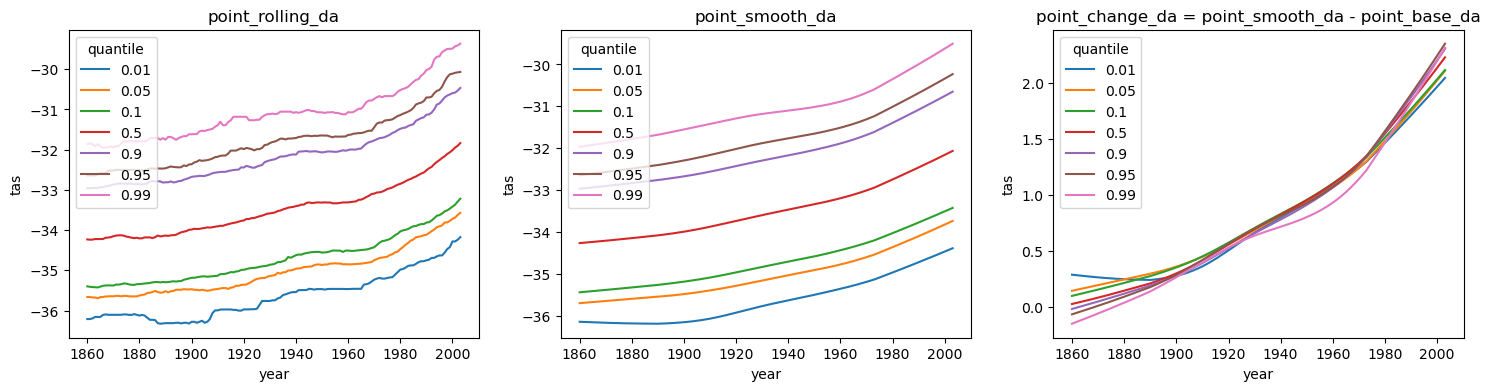

In [17]:
#(t): Quick look: the rolling quantiles, the smoothed ones, and the change from hist-nat's whole record (DEMO_EXPERIMENT)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
point_rolling_da.sel(experiment=DEMO_EXPERIMENT).plot.line(x='year', hue='quantile', ax=axes[0])
point_smooth_da.sel(experiment=DEMO_EXPERIMENT).plot.line(x='year', hue='quantile', ax=axes[1])
point_change_da.sel(experiment=DEMO_EXPERIMENT).plot.line(x='year', hue='quantile', ax=axes[2])
axes[0].set_title('point_rolling_da')
axes[1].set_title('point_smooth_da')
axes[2].set_title('point_change_da = point_smooth_da - point_base_da');

In [93]:
DEMO_EXPERIMENT, QRANGE_QUANTILES

('historical', (0.05, 0.95))

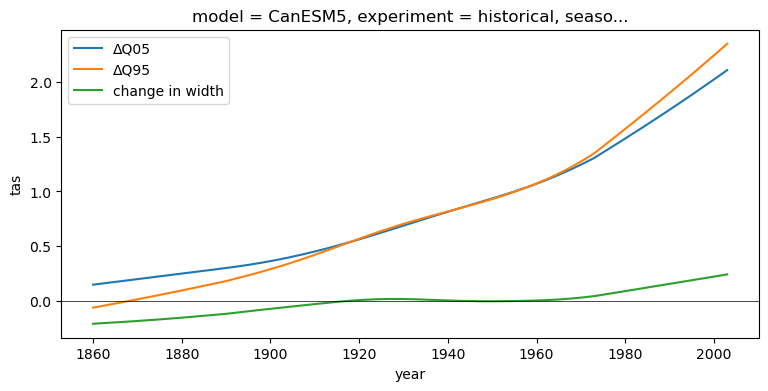

In [18]:
#(t): Quick look: the change in the two quantiles of the width test, and the change in width between them
low_da, high_da = (point_change_da.sel(experiment=DEMO_EXPERIMENT).sel(quantile=q, method='nearest') for q in QRANGE_QUANTILES)
fig, ax = plt.subplots(figsize=(9, 4))
low_da.plot(ax=ax, label=f'ΔQ{QRANGE_QUANTILES[0] * 100:02.0f}')
high_da.plot(ax=ax, label=f'ΔQ{QRANGE_QUANTILES[1] * 100:02.0f}')
(high_da - low_da).plot(ax=ax, label='change in width')
ax.axhline(0, color='k', lw=0.5)
ax.legend();

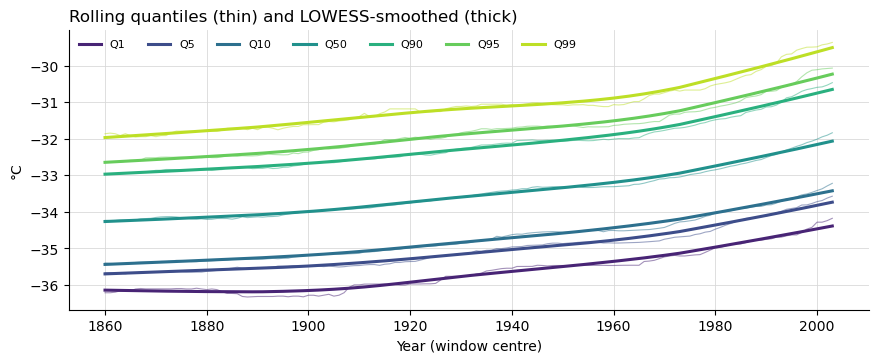

In [19]:
fig, ax = methods.smoothing_demo(point_rolling_da.sel(experiment=DEMO_EXPERIMENT),
                                 point_smooth_da.sel(experiment=DEMO_EXPERIMENT), units=var.units)

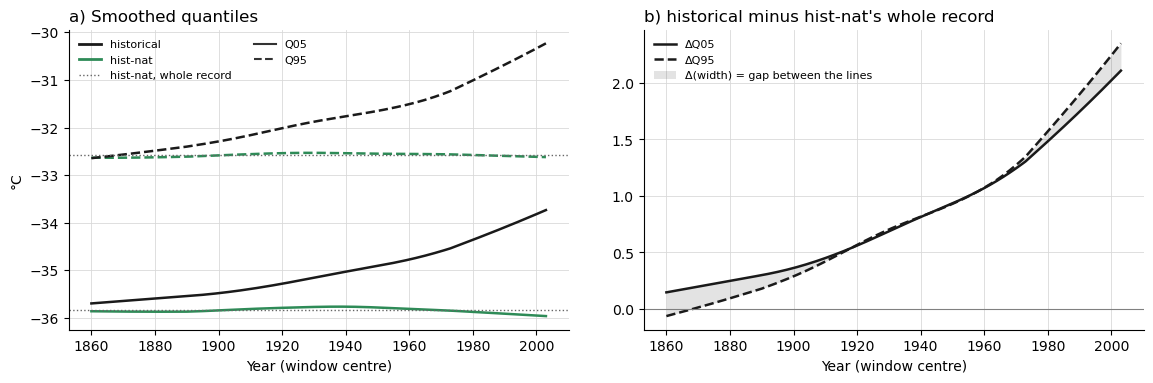

In [20]:
fig, axes = methods.quantile_change_demo(
    point_smooth_da.sel(experiment=[DEMO_EXPERIMENT, 'hist-nat']), point_base_da,
    DEMO_EXPERIMENT, quantiles=QRANGE_QUANTILES, units=var.units,
)

In [21]:
#(t): Check: the years with a complete rolling window, before and after smoothing (the first and last 10 have none)
for name, valid_da in [('rolling', point_rolling_da), ('smoothed', point_smooth_da)]:
    valid_da = valid_da.sel(experiment=DEMO_EXPERIMENT).isel(quantile=0).dropna('year')
    print(f'{name:9s} {int(valid_da.year[0])}-{int(valid_da.year[-1])} ({valid_da.sizes["year"]} years)')

rolling   1860-2003 (144 years)
smoothed  1860-2003 (144 years)


## 2. Change in width: the hist-nat bootstrap

**The question.** Has the distribution got wider or narrower, by more than natural variability can produce? The width is $W = Q_{95} - Q_{05}$ of the pooled values (members and years), and the change tested is

$$
\Delta W_{\mathrm{obs}} = W\left(x^{\mathrm{exp}}_{\text{final } L \text{ years}}\right) - W\left(x^{\mathrm{nat}}_{\text{whole record}}\right).
$$

**Its null distribution** comes from hist-nat alone. Trial $k$ draws $n = 10$ different hist-nat members and one random $L$-year window, pools their $nL = 210$ values, and takes their width minus the same whole-record width:

$$
\Delta W_k = W\left(x^{\mathrm{nat}}_{m \in S_k,\ y \in Y_k}\right) - W\left(x^{\mathrm{nat}}_{\text{whole record}}\right), \qquad k = 1, \ldots, N.
$$

Each $\Delta W_k$ is a change that natural variability and a 10-member, 21-year sample produce on their own. The two-sided p-value counts the trials at least as extreme as the observed change on either side:

$$
p = \min\left(1,\ \frac{2\,\min\left(1 + \#\{\Delta W_k \ge \Delta W_{\mathrm{obs}}\},\ 1 + \#\{\Delta W_k \le \Delta W_{\mathrm{obs}}\}\right)}{N + 1}\right),
$$

and the change is significant where $p < \alpha = 0.05$, i.e. outside the trials' central 95%.

**Why not a permutation test?** Permuting members between an experiment and hist-nat mixes the two ensembles in proportions set by their sizes, which differ between experiments, so the null changed from one experiment to the next. The bootstrap uses hist-nat alone, always with 10 members (the smallest ensemble), so one null per model serves every experiment, and it only has to be drawn once per model. For an experiment with more than 10 members, whose Q95 − Q05 is pinned down more precisely than 10 members can, the test is conservative.

The figure runs the test at one grid point (`DEMO_POINT`), step by step. Panel b shows real trials: their $\Delta$ values are the ones panel c is made of.

In [22]:
#(t): The test at one grid point, keeping its draws
bootstrap_demo_ds = sig.bootstrap_example(demo_experiment_da, demo_histnat_da, years=WINDOW, quantiles=QRANGE_QUANTILES,
                                          n_trials=10_000)
print(bootstrap_demo_ds)

<xarray.Dataset> Size: 740kB
Dimensions:            (member: 50, year: 164, exp_member: 65, final_year: 21,
                        trial: 10000)
Coordinates:
  * year               (year) int64 1kB 1850 1851 1852 1853 ... 2011 2012 2013
  * final_year         (final_year) int64 168B 1993 1994 1995 ... 2011 2012 2013
  * trial              (trial) int64 80kB 1 2 3 4 5 ... 9997 9998 9999 10000
Dimensions without coordinates: member, exp_member
Data variables:
    hist_nat           (member, year) float32 33kB -35.08 -32.54 ... -35.14
    final              (exp_member, final_year) float32 5kB -32.22 ... -31.63
    null               (trial) float32 40kB 0.3305 -0.2835 ... -0.02525 0.09837
    selected           (trial, member) bool 500kB False False ... False False
    window_start       (trial) int64 80kB 30 92 9 120 46 1 ... 62 55 116 57 114
    hist_nat_qrange    float64 8B 3.262
    experiment_qrange  float64 8B 3.505
    qrange_change      float64 8B 0.2425
    pvalue             f

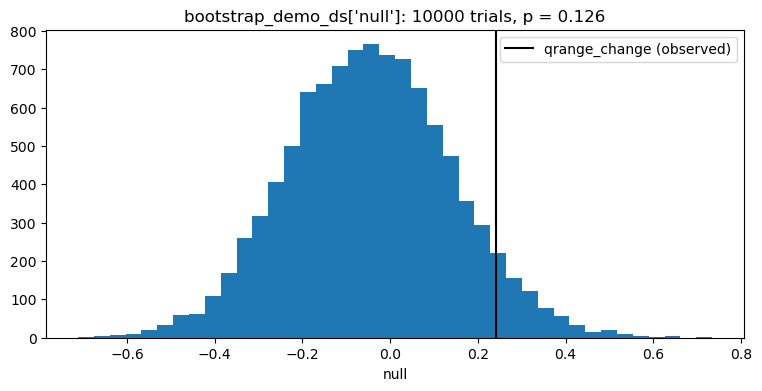

In [23]:
#(t): Quick look: the observed change in width against the changes of the hist-nat trials (the null)
fig, ax = plt.subplots(figsize=(9, 4))
bootstrap_demo_ds['null'].plot.hist(bins=40, ax=ax)
ax.axvline(float(bootstrap_demo_ds['qrange_change']), color='k', label='qrange_change (observed)')
ax.set_title(f"bootstrap_demo_ds['null']: {bootstrap_demo_ds.sizes['trial']} trials, p = {float(bootstrap_demo_ds['pvalue']):.3f}")
ax.legend();

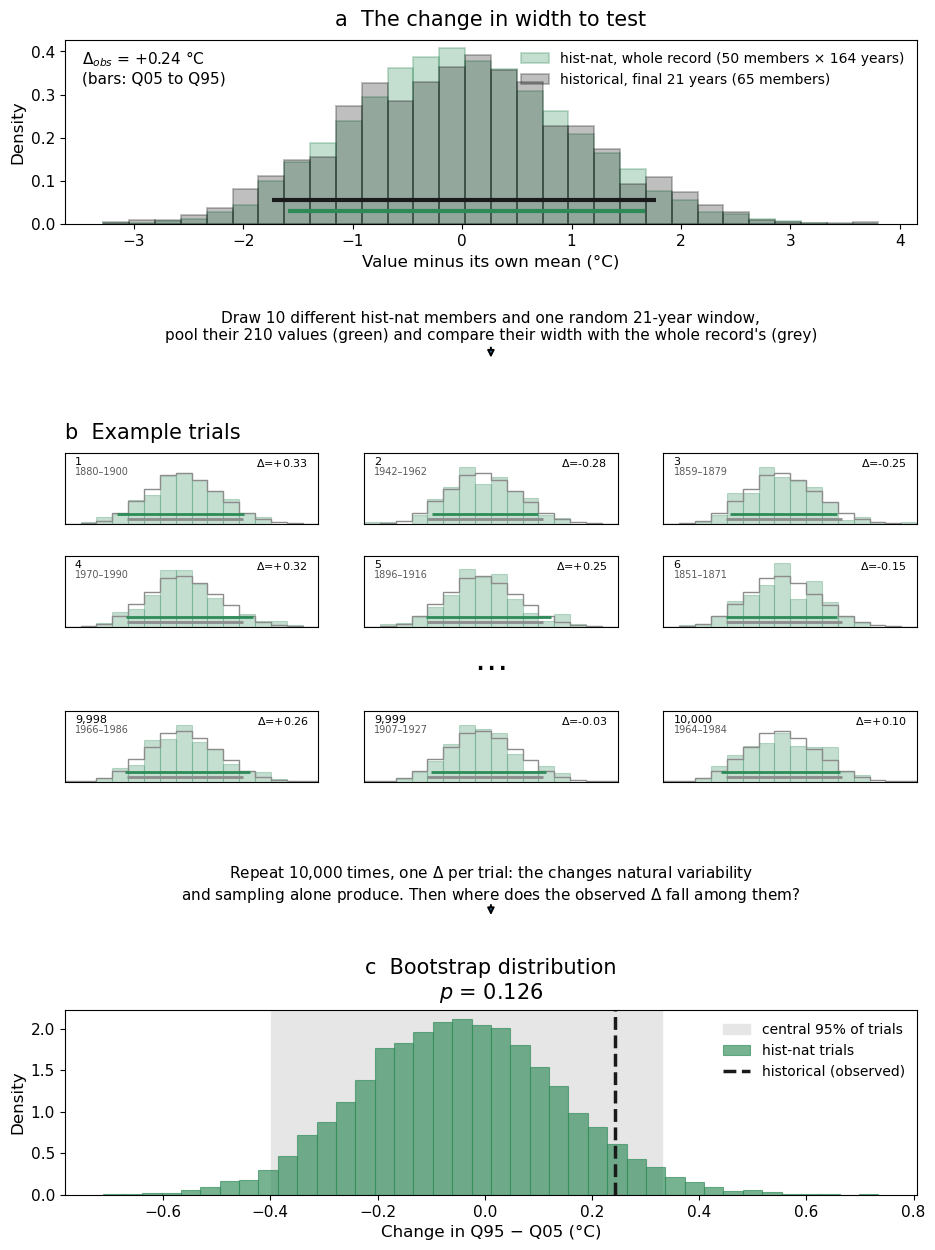

In [24]:
fig, axes = methods.bootstrap_schematic(bootstrap_demo_ds, DEMO_EXPERIMENT, units=var.units)

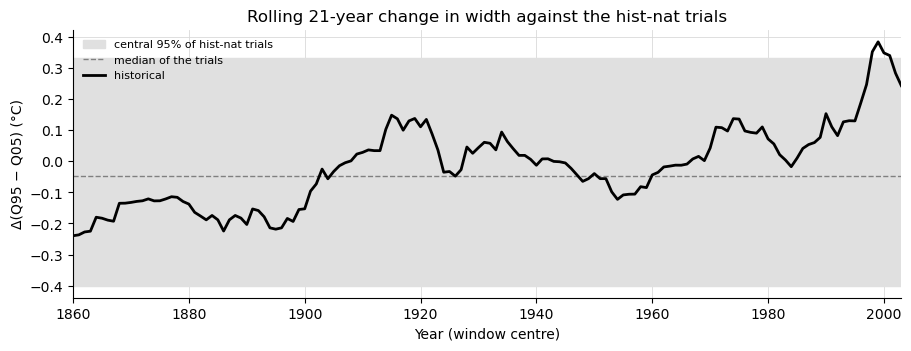

In [25]:
#(t): The same change through time: the experiment's rolling WINDOW-year width minus hist-nat's whole record
rolling_width_da = qc.rolling_quantile_range(demo_experiment_da, window=WINDOW, quantiles=QRANGE_QUANTILES)
null_low, null_mid, null_high = bootstrap_demo_ds['null'].quantile([0.025, 0.5, 0.975]).values
fig, ax = plt.subplots(figsize=(9, 3.4), layout='constrained')
ax.axhspan(null_low, null_high, color='0.88', label='central 95% of hist-nat trials')
ax.axhline(null_mid, color='0.5', ls='--', lw=1, label='median of the trials')
ax.plot(rolling_width_da.year, rolling_width_da - float(bootstrap_demo_ds['hist_nat_qrange']), color='k', lw=2,
        label=DEMO_EXPERIMENT)
ax.set(xlabel='Year (window centre)', ylabel=f'Δ(Q95 − Q05) ({var.units})',
       title=f'Rolling {WINDOW}-year change in width against the hist-nat trials')
ax.legend(frameon=False, fontsize=8)
formatting.style_ax(ax)

**The width of the internal variability.** Pooling 21 years of raw values into one width includes any forced change *within* those years: a warming trend slightly widens the pooled distribution. So each member first has its own experiment's forced response removed: the ensemble median in each year, smoothed with LOWESS (81 years),

$$
x'_{m,y} = x_{m,y} - \mathrm{LOWESS}\left(\operatorname{median}_m x_{m,y}\right),
$$

and the tests compare the width of the internal variability alone. The smoothing matters: subtracting the raw ensemble median would also strip its sampling noise from every member and shrink the spread, most for the smallest ensembles. `QRANGE_REMOVE_FORCED = False` tests the raw values instead.

In [26]:
#(t): DEMO_EXPERIMENT's forced response at the point (on year), and each member minus it (on member, year)
demo_forced_da = rc.forced_response(demo_experiment_da)
demo_internal_da = demo_experiment_da - demo_forced_da
print(demo_forced_da)

<xarray.DataArray 'tas' (year: 164)> Size: 1kB
-34.27 -34.27 -34.27 -34.26 -34.26 -34.26 ... -31.68 -31.65 -31.61 -31.57 -31.53
Coordinates:
  * year     (year) int64 1kB 1850 1851 1852 1853 1854 ... 2010 2011 2012 2013
    season   <U3 12B 'DJF'
    lon      float64 8B 117.5
    lat      float64 8B -80.0


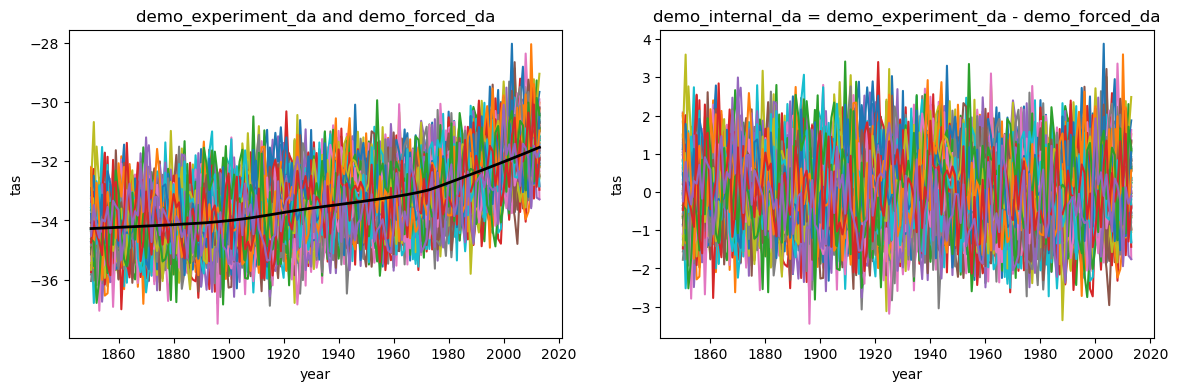

In [27]:
#(t): Quick look: the members with their forced response (black), and what is left once it is removed
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
demo_experiment_da.plot.line(x='year', hue='member', add_legend=False, ax=axes[0])
demo_forced_da.plot(ax=axes[0], color='k', lw=2)
demo_internal_da.plot.line(x='year', hue='member', add_legend=False, ax=axes[1])
axes[0].set_title('demo_experiment_da and demo_forced_da')
axes[1].set_title('demo_internal_da = demo_experiment_da - demo_forced_da');

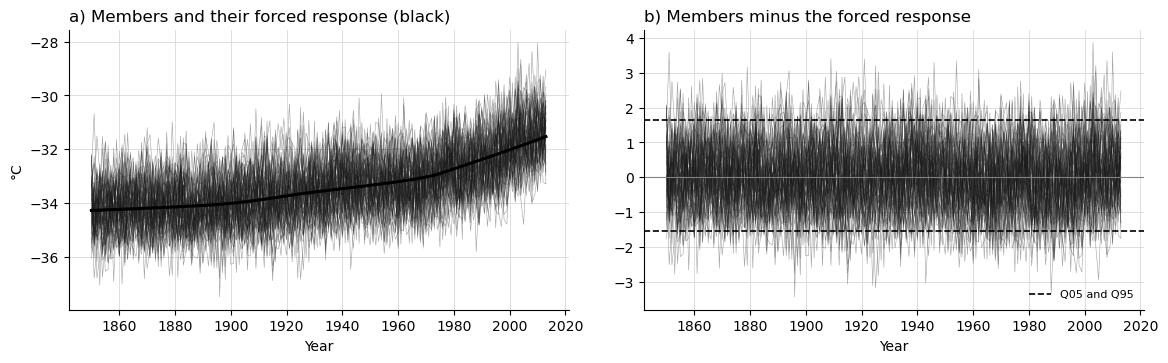

In [28]:
fig, axes = methods.forced_response_demo(demo_experiment_da, demo_forced_da, quantiles=QRANGE_QUANTILES,
                                         color=FORCING_COLORS[DEMO_EXPERIMENT], units=var.units)

In [29]:
QRANGE_REMOVE_FORCED = True

qrange_tree = rc.remove_forced_response(lesfmip_season_tree) if QRANGE_REMOVE_FORCED else lesfmip_season_tree
#(c): Persisted once: the width test and the tails in section 7 reuse it, and each use would redo the smoothing
qrange_tree = qrange_tree.persist()
wait(qrange_tree);

Now at every grid point. The bootstrap depends only on hist-nat, so it is drawn once per model and shared by all of that model's experiments.

In [94]:
sig.N_BOOTSTRAP_MEMBERS

10

In [95]:
%%time
#(t): The hist-nat bootstrap for every model, and every experiment's change tested against it
#(c): A loop on purpose: one bootstrap per model, shared by all of its experiments (numba, seconds each)
N_TRIALS = 1000
qrange_change_by_model = {}
for model_name, model_tree in qrange_tree.children.items():

    hist_nat_da = model_tree['hist-nat'][VARIABLE].dropna('member', how='all').persist()
    wait(hist_nat_da)

    qrange_change_by_model[model_name] = sig.qrange_significance(
        {exp: node[VARIABLE].dropna('member', how='all') for exp, node in model_tree.children.items()
         if exp != 'hist-nat'},
        hist_nat_da, years=WINDOW, quantiles=QRANGE_QUANTILES, n_trials=N_TRIALS, alpha=ALPHA, seed=0,
    )

qrange_change_ds = (xr.concat(list(qrange_change_by_model.values()), dim='model', join='outer')
                    .assign_coords(model=list(qrange_change_by_model)))

CPU times: user 1.56 s, sys: 93.6 ms, total: 1.65 s
Wall time: 194 ms


In [ ]:
storage.save(qrange_change_ds, result_path('qrange_change'))
qrange_change_ds

In [31]:
#(t): The result at the demonstration point (of qrange_tree, so with the forced response removed if QRANGE_REMOVE_FORCED)
qrange_change_ds.sel(**demo_sel, experiment=DEMO_EXPERIMENT).sel(**demo_latlon)

<xarray.Dataset> Size: 185B
Dimensions:             ()
Coordinates:
    season              <U3 12B 'DJF'
    lon                 float64 8B 117.5
    lat                 float64 8B -80.0
    experiment          <U12 48B 'historical'
    model               <U15 60B 'CanESM5'
Data variables:
    hist_nat_qrange     float64 8B 3.256
    experiment_qrange   float64 8B 3.322
    qrange_change       float64 8B 0.06608
    null_lower          float64 8B -0.3884
    null_upper          float64 8B 0.2948
    qrange_pvalue       float64 8B 0.4975
    qrange_significant  bool 1B False
Attributes: (5)

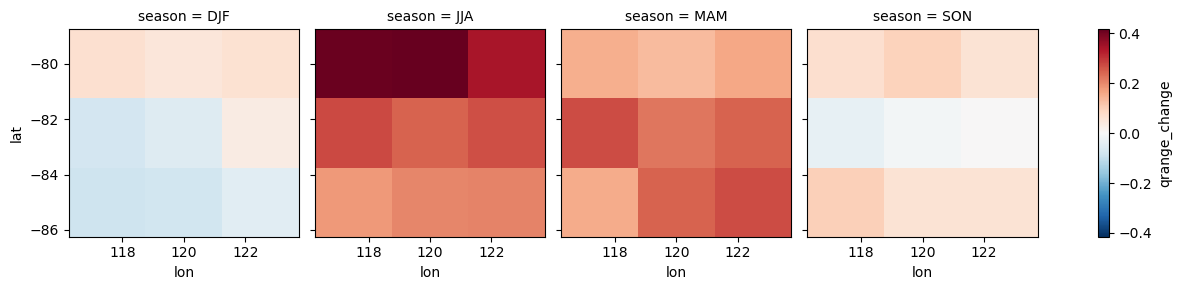

In [32]:
#(t): Quick look: the change in width for DEMO_MODEL and DEMO_EXPERIMENT, every season, on the plain lat-lon grid
qrange_change_ds['qrange_change'].sel(model=DEMO_MODEL, experiment=DEMO_EXPERIMENT).plot(
    x='lon', y='lat', col='season', cmap='RdBu_r', center=0);

## 3. Quantile response

The change in three quantiles, the final $L$ years of each experiment against hist-nat's whole record (members and years pooled):

$$
\Delta Q_p = Q_p\left(x^{\mathrm{exp}}_{\text{final } L \text{ years}}\right) - Q_p\left(x^{\mathrm{nat}}_{\text{whole record}}\right), \qquad p = 0.05,\ 0.5,\ 0.95,
$$

and the same for every 5th percentile as an Antarctic (area-weighted) mean. A flat curve of $\Delta Q_p$ against $p$ is a pure shift of the distribution; a rising curve means the warm tail moves more than the cold one.

In [ ]:
%%time
quantile_response_da = qc.quantile_response(lesfmip_season_tree, [0.05, 0.50, 0.95], years=WINDOW,
                                            variable=VARIABLE).rename('quantile_response').compute()

In [98]:
curve_quantiles = np.round(np.arange(0.05, 1.00, 0.05), 2)
curve_quantiles

array([0.05, 0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55,
       0.6 , 0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95])

In [ ]:
quantile_curve_da = sig.area_mean(qc.quantile_response(lesfmip_season_tree, curve_quantiles, years=WINDOW,
                                                       variable=VARIABLE)).rename('quantile_curve').compute()

In [33]:
storage.save(quantile_response_da, result_path('quantile_response'))
storage.save(quantile_curve_da, result_path('quantile_curve'));

13:34:25 INFO    extant.storage | writing DataArray (lat: 3, lon: 3, season: 4, quantile: 3, model: 2, experiment: 4) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/quantile_response.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:25 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/quantile_response.zarr
13:34:25 INFO    extant.storage | writing DataArray (season: 4, quantile: 19, model: 2, experiment: 4) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/quantile_curve.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr i

13:34:26 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/quantile_curve.zarr
CPU times: user 224 ms, sys: 25.4 ms, total: 249 ms
Wall time: 1.16 s


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be suppo

In [99]:
quantile_response_da

<xarray.DataArray 'quantile_response' (lat: 3, lon: 3, season: 4, quantile: 3,
                                       model: 2, experiment: 4)> Size: 7kB
2.899 -0.5889 0.2343 2.176 1.673 -0.3895 ... 1.607 1.324 -0.5514 0.2355 0.9095
Coordinates:
  * model       (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 24B 117.5 120.0 122.5
  * lat         (lat) float64 24B -85.0 -82.5 -80.0
  * quantile    (quantile) float64 24B 0.05 0.5 0.95

In [100]:
quantile_curve_da

<xarray.DataArray 'quantile_curve' (season: 4, quantile: 19, model: 2,
                                    experiment: 4)> Size: 5kB
2.87 -0.5519 0.2245 2.165 1.585 -0.289 ... 1.627 1.392 -0.47 0.2851 0.9781
Coordinates:
  * model       (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * quantile    (quantile) float64 152B 0.05 0.1 0.15 0.2 ... 0.8 0.85 0.9 0.95

In [35]:
#(t): The change in the three quantiles at the demonstration point, DEMO_MODEL
quantile_response_da.sel(**demo_sel).sel(**demo_latlon).to_pandas().round(2)

experiment,hist-GHG,hist-aer,hist-totalO3,historical
quantile,,,,
0.05,2.98,-0.54,0.23,2.27
0.50,3.12,-0.59,0.20,2.46
0.95,3.08,-0.64,0.18,2.51


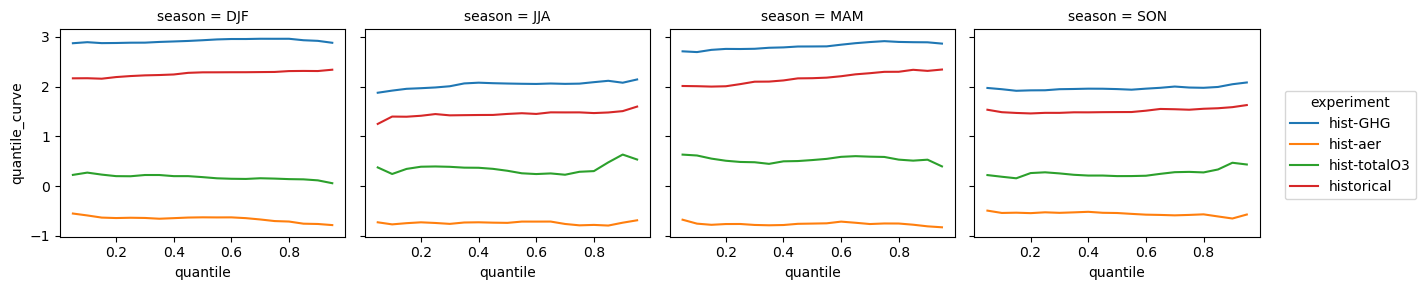

In [36]:
#(t): Quick look: DEMO_MODEL's Antarctic-mean change in every 5th percentile, one panel per season
quantile_curve_da.sel(model=DEMO_MODEL).plot.line(x='quantile', hue='experiment', col='season');

## 4. Mean change: Welch t-test and member-block permutation test

**Welch t-test.** The final $L$ years of each experiment against hist-nat's final $L$ years, members and years pooled, with sample means $\bar{x}$, variances $s^2$ and sizes $n = ML$:

$$
t = \frac{\bar{x}_{\mathrm{exp}} - \bar{x}_{\mathrm{nat}}}{\sqrt{s^2_{\mathrm{exp}}/n_{\mathrm{exp}} + s^2_{\mathrm{nat}}/n_{\mathrm{nat}}}},
\qquad
\nu = \frac{\left(s^2_{\mathrm{exp}}/n_{\mathrm{exp}} + s^2_{\mathrm{nat}}/n_{\mathrm{nat}}\right)^2}{\dfrac{(s^2_{\mathrm{exp}}/n_{\mathrm{exp}})^2}{n_{\mathrm{exp}}-1} + \dfrac{(s^2_{\mathrm{nat}}/n_{\mathrm{nat}})^2}{n_{\mathrm{nat}}-1}},
$$

with a two-sided p-value from Student's t distribution with $\nu$ degrees of freedom. The two samples at the demonstration point:

In [37]:
#(t): The final WINDOW years of each at the point, on (member, year)
demo_experiment_final_da = demo_experiment_da.isel(year=slice(-WINDOW, None))
demo_histnat_final_da = demo_histnat_da.isel(year=slice(-WINDOW, None))
demo_t_ds = sig.ttest_welch(demo_experiment_final_da.to_dataset(name=VARIABLE),
                            demo_histnat_final_da.to_dataset(name=VARIABLE), variable=VARIABLE)
print(f'{DEMO_EXPERIMENT}: {demo_experiment_final_da.size} values, mean {float(demo_experiment_final_da.mean()):.2f}')
print(f'{'hist-nat'}: {demo_histnat_final_da.size} values, mean {float(demo_histnat_final_da.mean()):.2f}')
print(demo_t_ds)

historical: 1365 values, mean -31.84
hist-nat: 1050 values, mean -34.28
<xarray.Dataset> Size: 44B
Dimensions:  ()
Coordinates:
    season   <U3 12B 'DJF'
    lon      float64 8B 117.5
    lat      float64 8B -80.0
Data variables:
    t        float64 8B 57.54
    p        float64 8B 0.0


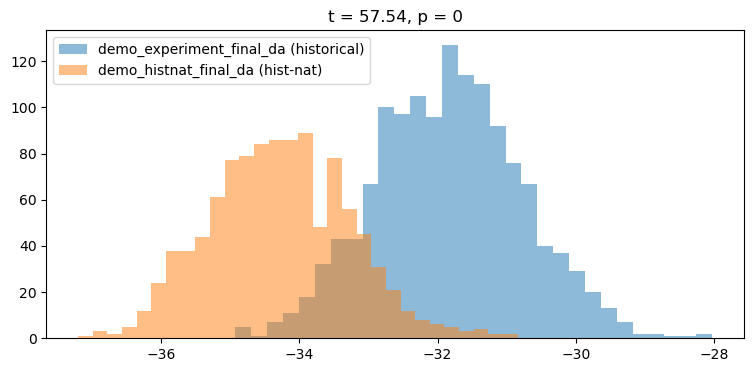

In [38]:
#(t): Quick look: the two samples as histograms
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(demo_experiment_final_da.values.ravel(), bins=30, alpha=0.5, label=f'demo_experiment_final_da ({DEMO_EXPERIMENT})')
ax.hist(demo_histnat_final_da.values.ravel(), bins=30, alpha=0.5, label=f'demo_histnat_final_da ({'hist-nat'})')
ax.set_title(f"t = {float(demo_t_ds['t']):.2f}, p = {float(demo_t_ds['p']):.3g}")
ax.legend();

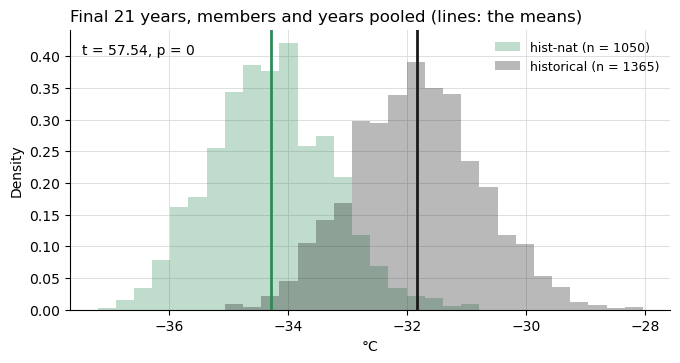

In [39]:
panels = methods.two_sample_demo(demo_experiment_final_da, demo_histnat_final_da, DEMO_EXPERIMENT,
                                 t=float(demo_t_ds.t), p=float(demo_t_ds.p), units=var.units,
                                 title=f'Final {WINDOW} years, members and years pooled (lines: the means)')

In [40]:
%%time
#(t): Welch t-test of the final WINDOW years against hist-nat, per model; no member dim left, so a Dataset
ttest_ds = datatree.tree_to_dataset(
    xr.DataTree.from_dict({model: xr.map_over_datasets(
        sig.ttest_welch,
        lesfmip_season_tree[model].isel(year=slice(-WINDOW, None)),
        lesfmip_season_tree[model]['hist-nat'].dataset.isel(year=slice(-WINDOW, None)),
        kwargs={'dims': ('year', 'member'), 'variable': VARIABLE},
    ) for model in lesfmip_season_tree}),
    dims=['model', 'experiment'],
).compute()
storage.save(ttest_ds, result_path('ttest'));

13:34:27 INFO    extant.storage | writing Dataset (model: 2, experiment: 5, lat: 3, lon: 3, season: 4) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/ttest.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:28 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/ttest.zarr
CPU times: user 151 ms, sys: 26.6 ms, total: 177 ms
Wall time: 705 ms


In [41]:
#(t): What was made, and its value at the demonstration point: the same t as above
print(ttest_ds)
ttest_ds.sel(**demo_sel, experiment=DEMO_EXPERIMENT).sel(**demo_latlon)

<xarray.Dataset> Size: 6kB
Dimensions:     (model: 2, experiment: 5, lat: 3, lon: 3, season: 4)
Coordinates:
  * model       (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 24B 117.5 120.0 122.5
  * lat         (lat) float64 24B -85.0 -82.5 -80.0
Data variables:
    t           (lat, lon, season, model, experiment) float64 3kB 63.94 ... 1...
    p           (lat, lon, season, model, experiment) float64 3kB 0.0 ... 1.7...


<xarray.Dataset> Size: 112B
Dimensions:     ()
Coordinates:
    model       <U7 28B 'CanESM5'
    experiment  <U10 40B 'historical'
    season      <U3 12B 'DJF'
    lon         float64 8B 117.5
    lat         float64 8B -80.0
Data variables:
    t           float64 8B 57.54
    p           float64 8B 0.0

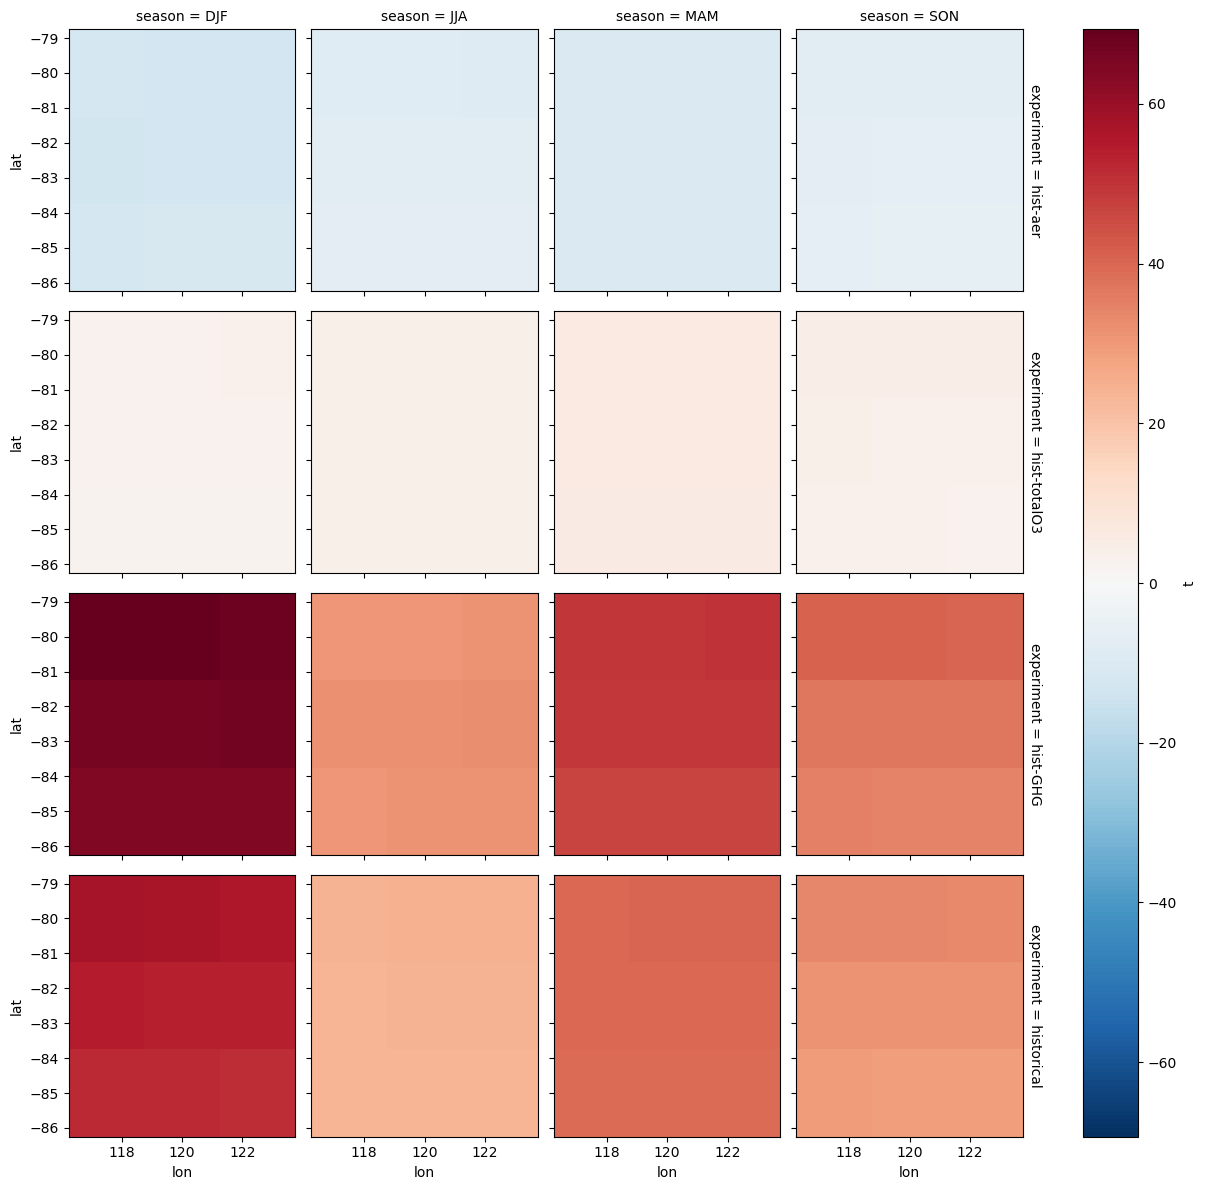

In [42]:
#(t): Quick look: t for DEMO_MODEL, experiments down and seasons across, on the plain lat-lon grid
ttest_ds['t'].sel(model=DEMO_MODEL, experiment=config.FORCED_EXPERIMENTS).plot(
    x='lon', y='lat', row='experiment', col='season', cmap='RdBu_r', center=0);

### Member-block permutation test

The Welch t-test above pools `WINDOW` years × N members as if every value were independent. But a member's years are serially correlated, so the pooled test is overconfident: in synthetic data with a lag-1 autocorrelation of 0.6, it rejects a true null 29% of the time at p < 0.05, against 5% for this test. (Antarctic seasonal means are usually less correlated than that, so the effect here is smaller, but it is there.)

Members, however, are independent realisations. So this test permutes **whole members** between the experiment and hist-nat, keeping each member's years together as a block. Because every member covers the same years, permuting whole members is the same as permuting member means, so the test runs as one matrix product per batch of permutations.

The test statistic is the difference in means, $\Delta = \bar{x}_{\mathrm{exp}} - \bar{x}_{\mathrm{nat}}$. Each permutation relabels $M_{\mathrm{exp}}$ of the pooled members as the experiment and the other $M_{\mathrm{nat}}$ as hist-nat, keeping each member's years together, and computes the same $\Delta$; the p-value counts the permutations at least as extreme, as for the bootstrap. Step by step, at the demonstration point:

In [43]:
permutation_demo_ds = rc.permutation_example(demo_experiment_da, demo_histnat_da, years=WINDOW, n_permutations=5000)
print(permutation_demo_ds)

<xarray.Dataset> Size: 665kB
Dimensions:        (exp_member: 65, final_year: 21, ref_member: 50,
                    trial: 5000, pool_member: 115)
Coordinates:
  * trial          (trial) int64 40kB 1 2 3 4 5 6 ... 4996 4997 4998 4999 5000
  * final_year     (final_year) int64 168B 1993 1994 1995 ... 2011 2012 2013
Dimensions without coordinates: exp_member, ref_member, pool_member
Data variables:
    experiment     (exp_member, final_year) float32 5kB -32.22 -31.81 ... -31.63
    reference      (ref_member, final_year) float32 4kB -33.21 -33.97 ... -35.14
    permutations   (trial) float64 40kB 0.3345 -0.05899 ... 0.03976 0.08565
    is_experiment  (trial, pool_member) bool 575kB False True ... False False
    mean_change    float32 4B 2.446
    pvalue         float64 8B 0.0003999
Attributes: (1)


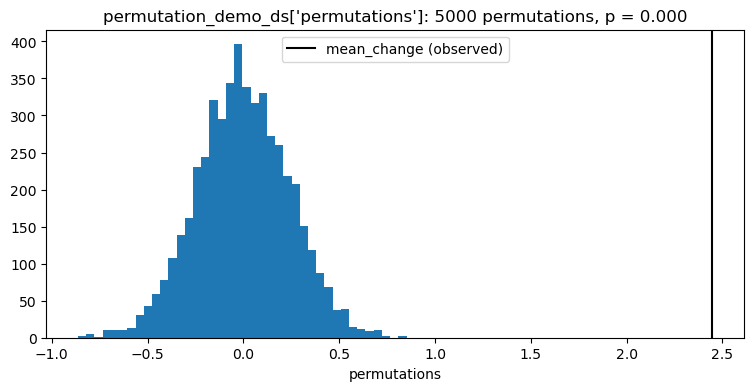

In [44]:
#(t): Quick look: the observed difference in means against the differences after permuting whole members (the null)
fig, ax = plt.subplots(figsize=(9, 4))
permutation_demo_ds['permutations'].plot.hist(bins=40, ax=ax)
ax.axvline(float(permutation_demo_ds['mean_change']), color='k', label='mean_change (observed)')
ax.set_title(f"permutation_demo_ds['permutations']: {permutation_demo_ds.sizes['trial']} permutations, "
             f"p = {float(permutation_demo_ds['pvalue']):.3f}")
ax.legend();

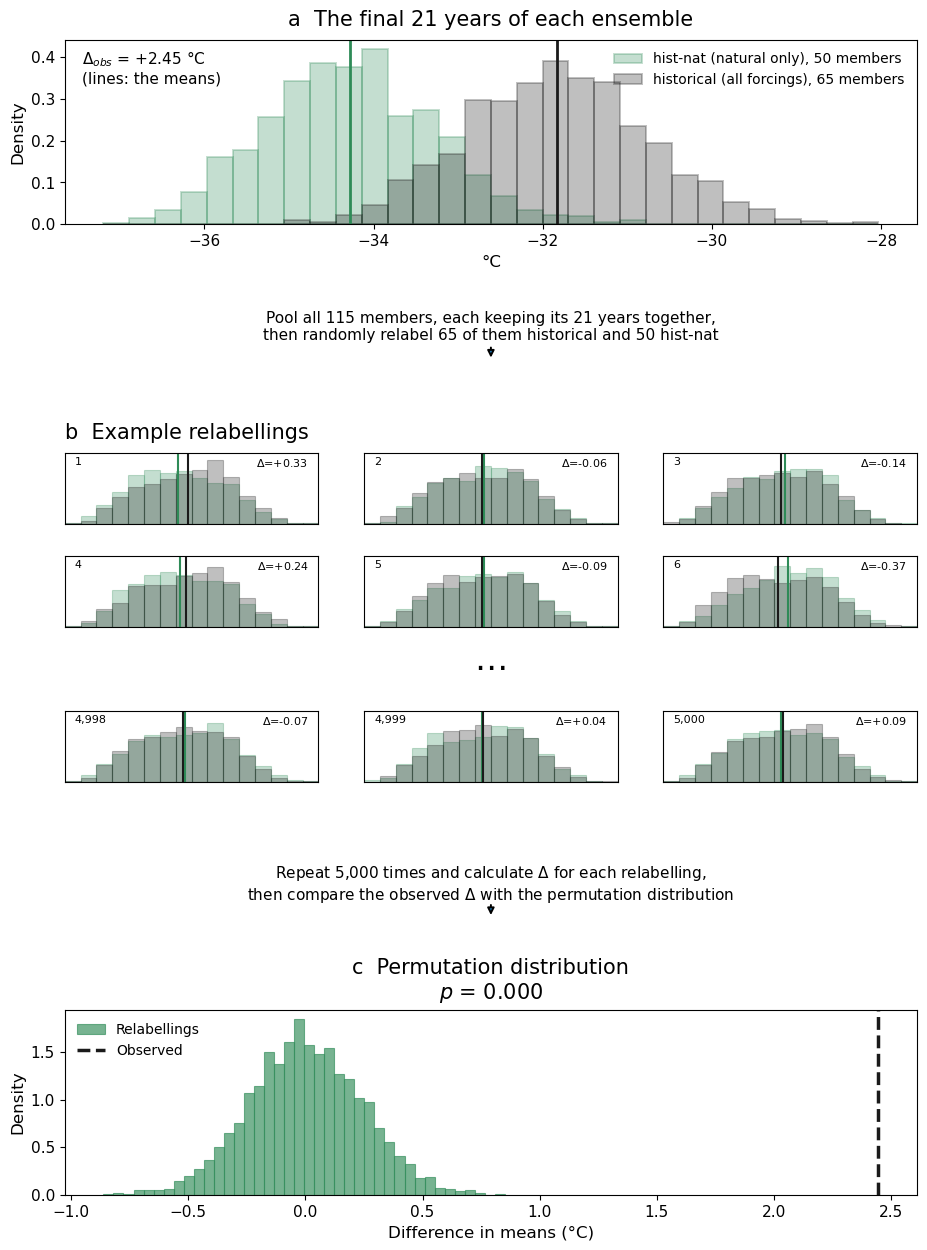

In [45]:
fig, axes = methods.permutation_schematic(permutation_demo_ds, DEMO_EXPERIMENT, units=var.units)

In [46]:
%%time
#(t): Member-block permutation test of the mean change, final WINDOW years vs hist-nat, everywhere
mean_block_ds = rc.member_block_test(lesfmip_season_tree, years=WINDOW, n_permutations=5000, variable=VARIABLE)
storage.save(mean_block_ds, result_path('mean_block'));

13:34:31 INFO    extant.storage | writing Dataset (model: 2, experiment: 4, lat: 3, lon: 3, season: 4) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/mean_block.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:32 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/mean_block.zarr
CPU times: user 1.91 s, sys: 23.4 ms, total: 1.93 s
Wall time: 783 ms


In [47]:
#(t): What was made, and its value at the demonstration point: the same change as above (p differs with the permutations)
print(mean_block_ds)
mean_block_ds.sel(**demo_sel, experiment=DEMO_EXPERIMENT).sel(**demo_latlon)

<xarray.Dataset> Size: 2kB
Dimensions:      (model: 2, experiment: 4, lat: 3, lon: 3, season: 4)
Coordinates:
  * model        (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment   (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * season       (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon          (lon) float64 24B 117.5 120.0 122.5
  * lat          (lat) float64 24B -85.0 -82.5 -80.0
Data variables:
    mean_change  (model, experiment, lat, lon, season) float32 1kB 2.948 ... ...
    pvalue       (model, experiment, lat, lon, season) float32 1kB 0.0003999 ...
Attributes: (2)


<xarray.Dataset> Size: 104B
Dimensions:      ()
Coordinates:
    model        <U7 28B 'CanESM5'
    experiment   <U10 40B 'historical'
    season       <U3 12B 'DJF'
    lon          float64 8B 117.5
    lat          float64 8B -80.0
Data variables:
    mean_change  float32 4B 2.446
    pvalue       float32 4B 0.0003999
Attributes: (2)

In [48]:
#(t): % of the area each test calls significant (p < 0.05), averaged over models and seasons
def significant_area(pvalue):
    return 100 * sig.area_mean((pvalue < 0.05).where(pvalue.notnull())).mean(['model', 'season'])

pd.DataFrame({
    'Welch t-test (years pooled)': significant_area(ttest_ds.p.sel(experiment=config.FORCED_EXPERIMENTS)).to_series(),
    'member-block test': significant_area(mean_block_ds.pvalue.sel(experiment=config.FORCED_EXPERIMENTS)).to_series(),
}).round(0)

,Welch t-test (years pooled),member-block test
experiment,,
hist-aer,100.0,100.0
hist-totalO3,68.0,50.0
hist-GHG,100.0,100.0
historical,100.0,100.0


## 5. Signal to noise

**Signal.** The forced response of each experiment is its ensemble mean, smoothed with LOWESS (81 years); the signal is the experiment's minus hist-nat's:

$$
S(t) = F_{\mathrm{exp}}(t) - F_{\mathrm{nat}}(t), \qquad F(t) = \mathrm{LOWESS}\left(\tfrac{1}{M}\textstyle\sum_m x_{m,t}\right).
$$

(The ensemble means are smoothed as anomalies from their own whole-record mean, which is then added back; LOWESS commutes with adding a constant, so this changes nothing but the numerics.)

**Noise.** Each member's deviation from its own experiment's forced response, $x_{m,y} - F(y)$, pooled over members and a rolling $L$-year window, gives a standard deviation $\sigma(t)$ for each experiment; the noise pools the experiment's and hist-nat's:

$$
N(t) = \sqrt{\tfrac{1}{2}\left(\sigma^2_{\mathrm{exp}}(t) + \sigma^2_{\mathrm{nat}}(t)\right)}, \qquad \mathrm{S/N}(t) = \frac{S(t)}{N(t)}.
$$

$|\mathrm{S/N}| \ge 2$ counts as emerged. This asks a stricter question than the tests in section 4: whether the shift stands out from year-to-year noise, i.e. whether a single realisation, like the real world, would show it.

In [49]:
#(t): Each experiment's whole-record mean (no member dim, so a Dataset), and its anomalies from it (a tree)
base_mean_ds = datatree.reduce_to_dataset(lesfmip_season_tree, lambda ds: ds.mean(dim=['year', 'member']))
lesfmip_season_anom_tree = lesfmip_season_tree - datatree.dataset_to_tree(base_mean_ds, like=lesfmip_season_tree)

In [50]:
#(t): The smoothed ensemble-mean anomaly of each experiment
lesfmip_mm_signal_ds = datatree.reduce_to_dataset(lesfmip_season_anom_tree, lambda ds: ds.mean(dim='member'))
lesfmip_mm_signal_ds = qc.lowess_xarray(lesfmip_mm_signal_ds, core_dims='year').persist()
wait(lesfmip_mm_signal_ds);

In [51]:
#(t): Each member's deviation from its experiment's forced response, and their rolling standard deviation
lesfmip_detrend_tree = (lesfmip_season_anom_tree
                   - datatree.dataset_to_tree(lesfmip_mm_signal_ds, like=lesfmip_season_anom_tree)).persist()
wait(lesfmip_detrend_tree)
lesfmip_experiment_noise_ds = datatree.reduce_to_dataset(lesfmip_detrend_tree, partial(qc.rolling_std, window=WINDOW))

In [52]:
%%time
#(t): Pooled noise, signal against hist-nat, and S/N (slow)
lesfmip_noise_ds = np.sqrt(0.5 * (lesfmip_experiment_noise_ds.sel(experiment='hist-nat') ** 2
                                  + lesfmip_experiment_noise_ds ** 2)).compute()
lesfmip_forced_ds = (lesfmip_mm_signal_ds + base_mean_ds).compute()
lesfmip_signal_ds = lesfmip_forced_ds - lesfmip_forced_ds.sel(experiment='hist-nat')
lesfmip_seasonal_sn_ds = (lesfmip_signal_ds / lesfmip_noise_ds).compute()

storage.save(lesfmip_signal_ds, result_path('signal'))
storage.save(lesfmip_noise_ds, result_path('noise'))
storage.save(lesfmip_seasonal_sn_ds, result_path('sn'));

13:34:34 INFO    extant.storage | writing Dataset (model: 2, experiment: 5, year: 164, season: 4, lon: 3, lat: 3) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/signal.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:35 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/signal.zarr
13:34:35 INFO    extant.storage | writing Dataset (year: 164, lat: 3, lon: 3, season: 4, model: 2, experiment: 5) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/noise.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:35 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/noise.zarr
13:34:35 INFO    extant.storage | writing Dataset (model: 2, experiment: 5, year: 164, season: 4, lon: 3, lat: 3) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/sn.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:36 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/sn.zarr
CPU times: user 156 ms, sys: 62.4 ms, total: 218 ms
Wall time: 1.99 s


In [53]:
#(t): What was made: the signal, the noise and S/N
print(lesfmip_signal_ds, '\n')
print(lesfmip_noise_ds, '\n')
print(lesfmip_seasonal_sn_ds)

<xarray.Dataset> Size: 474kB
Dimensions:     (model: 2, experiment: 5, year: 164, season: 4, lon: 3, lat: 3)
Coordinates:
  * model       (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2010 2011 2012 2013
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 24B 117.5 120.0 122.5
  * lat         (lat) float64 24B -85.0 -82.5 -80.0
Data variables:
    tas         (model, experiment, lat, lon, year, season) float64 472kB -0.... 

<xarray.Dataset> Size: 474kB
Dimensions:     (year: 164, lat: 3, lon: 3, season: 4, model: 2, experiment: 5)
Coordinates:
  * model       (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2010 2011 2012 2013
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
 

The three parts at the demonstration point, picked out of the results, printed, plotted plainly, then the method figure:

In [54]:
#(t): The demonstration point picked out of the results, on (experiment, year)
point_forced_da = lesfmip_forced_ds[VARIABLE].sel(**demo_sel).sel(**demo_latlon)
point_noise_da = lesfmip_noise_ds[VARIABLE].sel(**demo_sel).sel(**demo_latlon)
point_sn_da = lesfmip_seasonal_sn_ds[VARIABLE].sel(**demo_sel).sel(**demo_latlon)
demo_ensemble_mean_da = (xr.concat([demo_experiment_da.mean('member'), demo_histnat_da.mean('member')], dim='experiment')
                         .assign_coords(experiment=[DEMO_EXPERIMENT, 'hist-nat']))
print(point_sn_da)

<xarray.DataArray 'tas' (experiment: 5, year: 164)> Size: 7kB
-0.08907 -0.07937 -0.06933 -0.06025 -0.05054 ... 2.61 2.656 2.721 2.735 2.783
Coordinates:
    model       <U7 28B 'CanESM5'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * year        (year) int64 1kB 1850 1851 1852 1853 ... 2010 2011 2012 2013
    season      <U3 12B 'DJF'
    lon         float64 8B 117.5
    lat         float64 8B -80.0


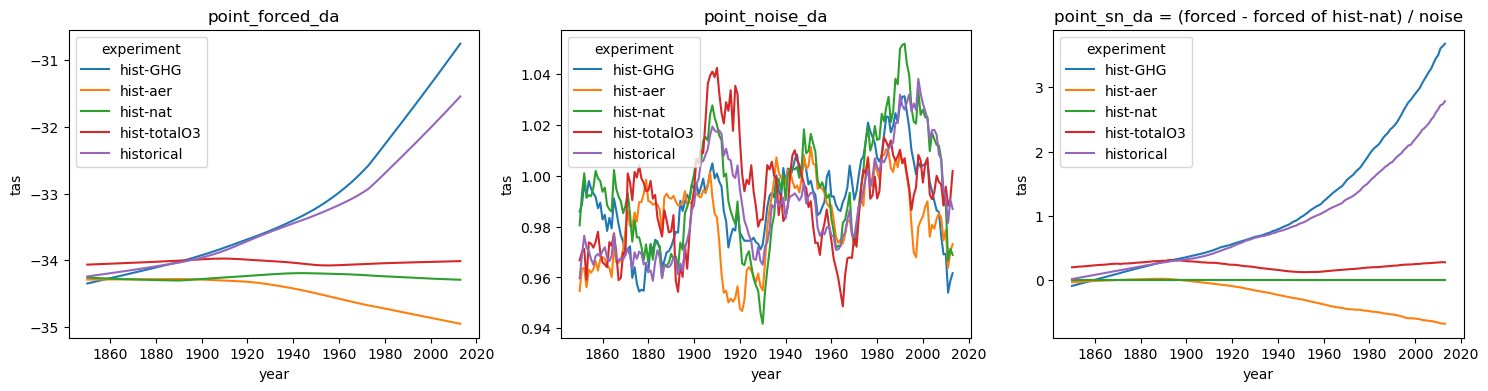

In [55]:
#(t): Quick look: each experiment's forced response (smoothed ensemble mean), the noise, and S/N
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
point_forced_da.plot.line(x='year', hue='experiment', ax=axes[0])
point_noise_da.plot.line(x='year', hue='experiment', ax=axes[1])
point_sn_da.plot.line(x='year', hue='experiment', ax=axes[2])
axes[0].set_title('point_forced_da')
axes[1].set_title('point_noise_da')
axes[2].set_title('point_sn_da = (forced - forced of hist-nat) / noise');

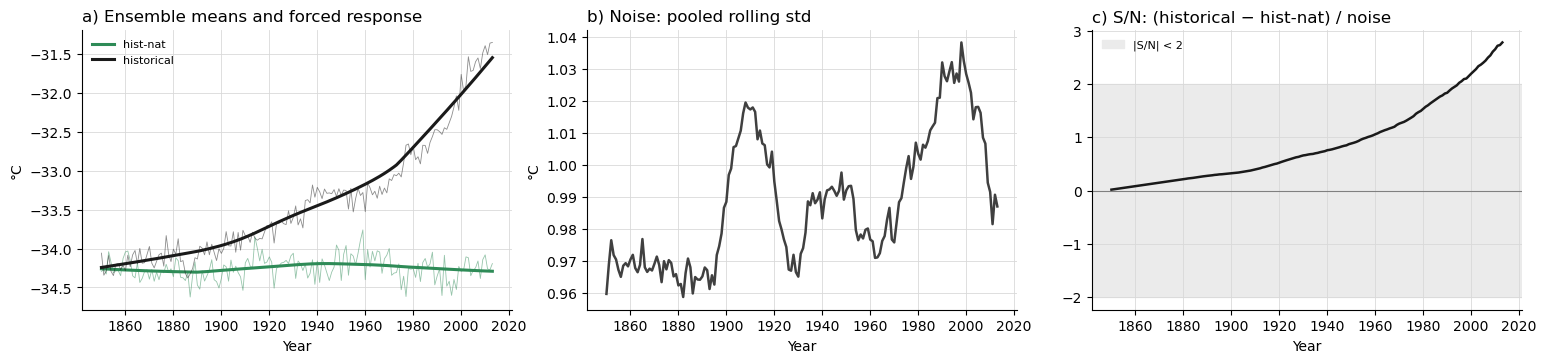

In [56]:
fig, axes = methods.signal_to_noise_demo(
    demo_ensemble_mean_da,
    point_forced_da.sel(experiment=[DEMO_EXPERIMENT, 'hist-nat']),
    point_noise_da.sel(experiment=DEMO_EXPERIMENT),
    point_sn_da.sel(experiment=DEMO_EXPERIMENT),
    DEMO_EXPERIMENT, units=var.units,
)

## 6. Additivity: each forcing's change from its own baseline

Single-forcing experiments contain *only* their forcing, so each one's response is best measured from its own pre-industrial baseline (1850–1900), not from hist-nat's full record. Measuring everything from hist-nat's full-record mean subtracts hist-nat's average volcanic cooling from every single forcing, so a sum of four forcings would subtract it four times while historical subtracts it once.

The **residual**, historical − (nat + GHG + aer + O3), holds everything the parts leave out: land use (hist-lu, which should be very small over Antarctica), any other forcing, and non-additive interaction between forcings. Fractions of historical are only given where |historical| ≥ 0.25 °C; elsewhere they blow up.

$$
\Delta_e = \bar{x}^{\,e}_{\text{final } L \text{ years}} - \bar{x}^{\,e}_{1850\text{–}1900},
\qquad
\text{residual} = \Delta_{\mathrm{historical}} - \left(\Delta_{\mathrm{nat}} + \Delta_{\mathrm{GHG}} + \Delta_{\mathrm{aer}} + \Delta_{\mathrm{O_3}}\right).
$$

In [57]:
#(t): Each experiment's change: final WINDOW years minus its own 1850-1900 baseline, ensemble mean
own_changes_da = rc.own_baseline_change(lesfmip_season_tree, years=WINDOW, baseline=slice(1850, 1900),
                                        variable=VARIABLE).rename('own_change').compute()
storage.save(own_changes_da, result_path('own_changes'));

13:34:37 INFO    extant.storage | writing DataArray (lat: 3, lon: 3, season: 4, model: 2, experiment: 5) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/own_changes.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:37 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/own_changes.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be suppo

<xarray.DataArray 'own_change' (lat: 3, lon: 3, season: 4, model: 2,
                                experiment: 5)> Size: 1kB
2.751 -0.668 -0.05778 -0.1307 2.063 ... 1.404 -0.3916 -0.005417 0.258 0.9014
Coordinates:
  * model       (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment  (experiment) object 40B 'hist-GHG' 'hist-aer' ... 'historical'
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 24B 117.5 120.0 122.5
  * lat         (lat) float64 24B -85.0 -82.5 -80.0


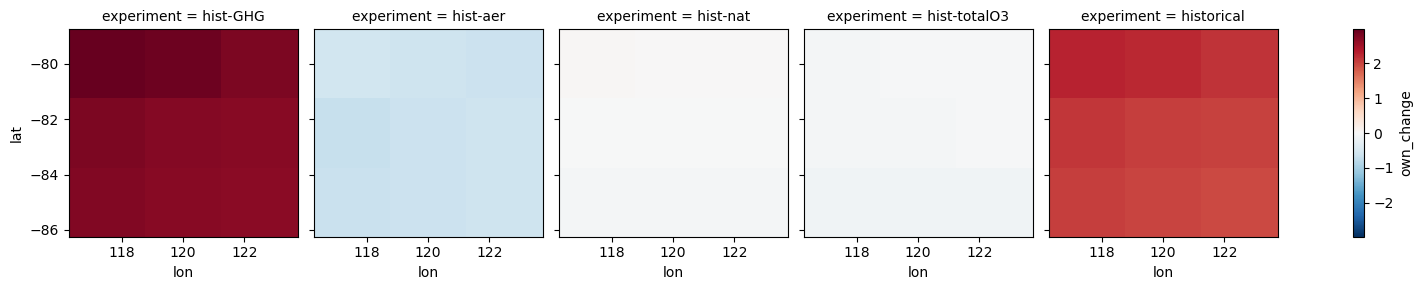

In [58]:
#(t): What was made, and a quick look: DEMO_MODEL's change from its own 1850-1900 baseline in one season
print(own_changes_da)
own_changes_da.sel(**demo_sel).plot(x='lon', y='lat', col='experiment', cmap='RdBu_r', center=0);

## 7. Mean and variability change: the inputs

The combined figures in notebook 04 put the mean response next to the change in width and in each tail:

- the **mean response**, the final $L$ years of each experiment minus hist-nat over the same years, members pooled: exactly the difference the t-test and the member-block test test;
- the **tails**: the warm tail's length $Q_{95} - Q_{50}$ and the cold tail's $Q_{50} - Q_{05}$, each experiment's final years against hist-nat's whole record, from the same data as the width test (`qrange_tree`), so that

$$
\Delta(Q_{95} - Q_{50}) + \Delta(Q_{50} - Q_{05}) = \Delta(Q_{95} - Q_{05}).
$$

In [59]:
%%time
mean_response_da = rc.mean_response(lesfmip_season_tree, years=WINDOW, variable=VARIABLE).rename('mean_response').compute()
tails_ds = rc.tail_changes(qrange_tree, years=WINDOW, variable=VARIABLE).compute()
storage.save(mean_response_da, result_path('mean_response'))
storage.save(tails_ds, result_path('tails'));

13:34:38 INFO    extant.storage | writing DataArray (lat: 3, lon: 3, season: 4, model: 2, experiment: 4) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/mean_response.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:38 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/mean_response.zarr
13:34:38 INFO    extant.storage | writing Dataset (model: 2, experiment: 4, season: 4, lon: 3, lat: 3) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/tails.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be suppo

13:34:39 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/tails.zarr
CPU times: user 205 ms, sys: 69.4 ms, total: 275 ms
Wall time: 1.63 s


In [60]:
#(t): What was made
print(mean_response_da, '\n')
print(tails_ds)

<xarray.DataArray 'mean_response' (lat: 3, lon: 3, season: 4, model: 2,
                                   experiment: 4)> Size: 1kB
2.948 -0.6171 0.2099 2.287 1.677 -0.3732 ... 1.654 1.423 -0.4743 0.2697 0.9298
Coordinates:
  * model       (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment  (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * season      (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon         (lon) float64 24B 117.5 120.0 122.5
  * lat         (lat) float64 24B -85.0 -82.5 -80.0 

<xarray.Dataset> Size: 16kB
Dimensions:            (model: 2, experiment: 4, season: 4, lon: 3, lat: 3)
Coordinates:
  * model              (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment         (experiment) object 32B 'hist-GHG' ... 'historical'
  * season             (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lon                (lon) float64 24B 117.5 120.0 122.5
  * lat                (lat) float64 24B -85.0 -82.5 -80.0
Data variables:
    upper_

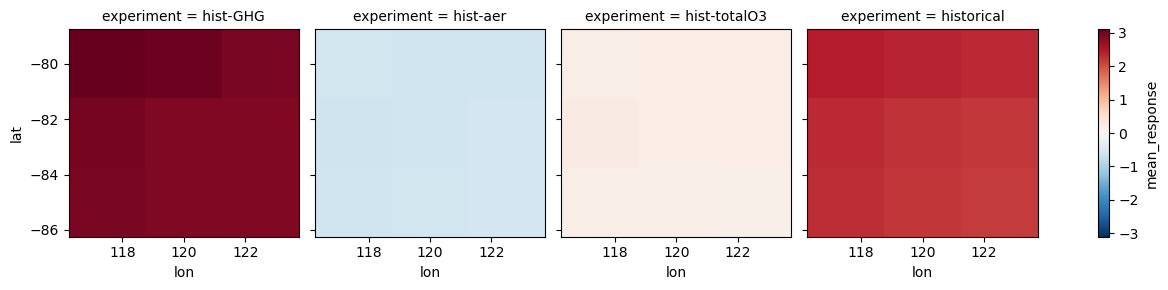

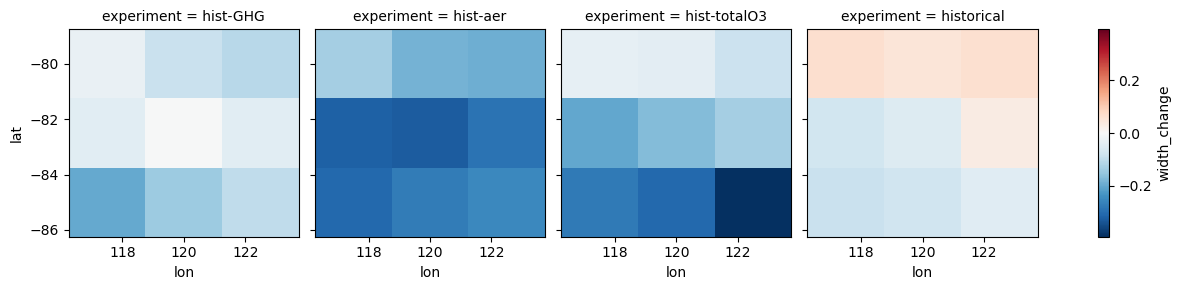

In [61]:
#(t): Quick look: DEMO_MODEL's mean response and change in width in one season
mean_response_da.sel(**demo_sel).plot(x='lon', y='lat', col='experiment', cmap='RdBu_r', center=0)
tails_ds['width_change'].sel(**demo_sel).plot(x='lon', y='lat', col='experiment', cmap='RdBu_r', center=0);

## 8. Zonal means: the change at each latitude

Bracegirdle et al. (2024, *npj Clim. Atmos. Sci.* 7, 276) show the change in the low extremes, the mean, the high extremes and the width between them against latitude, averaged round the pole, with the sea-ice edge marked. Notebook 04 (section 9) draws the same from the changes above, for every model on its own. This section tests the zonal means themselves, with the tests used for the maps:

- **the mean**: the member-block permutation test (section 4) on zonal-mean data. A mean is linear, so the change in the zonal mean is the zonal mean of the change at each point: the test is of exactly the plotted line.
- **the width**: the hist-nat bootstrap (section 2), on `qrange_tree`. A trial draws the same members and years at every grid point, so its changes averaged over longitude $\lambda$ are one draw of what natural variability alone does to the zonal-mean width:

$$
\overline{\Delta W}_k(\varphi) = \frac{1}{N_\lambda} \sum_{\lambda} \Delta W_k(\varphi, \lambda), \qquad k = 1, \ldots, N,
$$

and the observed $\overline{\Delta W}_{\mathrm{obs}}(\varphi)$ is compared with these trials as before. Averaging over longitude cancels much of the noise, so a zonal-mean change can be significant where few single points are.

The zonal-mean width is the average of the *local* widths (how much a season varies at each point), not the width of the zonal-mean series, in which anomalies at different longitudes would cancel. The low and high extremes have no test of their own. The code is in `extant/zonal.py`.

In [62]:
%%time
#(t): Both tests on the zonal means: the mean on the seasonal means, the width on qrange_tree (as in section 2)
zonal_mean_ds = zonal.mean_test(lesfmip_season_tree, years=WINDOW, n_permutations=5000, variable=VARIABLE)
zonal_width_ds = zonal.width_test(qrange_tree, years=WINDOW, quantiles=QRANGE_QUANTILES, n_trials=N_TRIALS,
                                  alpha=ALPHA, variable=VARIABLE)
storage.save(zonal_mean_ds, result_path('zonal_mean_test'))
storage.save(zonal_width_ds, result_path('zonal_width_test'));

13:34:41 INFO    extant.storage | writing Dataset (model: 2, experiment: 4, lat: 3, season: 4) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/zonal_mean_test.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/core/array.py:4275: UserWarning: The dtype `StringDType()` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  meta = AsyncArray._create_metadata_v3(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be su

13:34:41 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/zonal_mean_test.zarr
13:34:41 INFO    extant.storage | writing Dataset (model: 2, experiment: 4, lat: 3, season: 4) to /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/zonal_width_test.zarr


/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/api/asynchronous.py:227: UserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(
/apps/jasmin/jaspy/miniforge_envs/jaspy3.12/mf3-25.3.0-3/envs/jaspy3.12-mf3-25.3.0-3-v20250704/lib/python3.12/site-packages/zarr/codecs/vlen_utf8.py:44: UserWarning: The codec `vlen-utf8` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr i

13:34:42 INFO    extant.storage | saved /work/scratch-pw4/aborow/ExtAnt/results/tas/sample/zonal_width_test.zarr
CPU times: user 2.16 s, sys: 143 ms, total: 2.3 s
Wall time: 1.93 s


In [63]:
#(t): What was made: the zonal-mean change in the mean and in the width, with their p-values, on latitude
print(zonal_mean_ds, '\n')
print(zonal_width_ds)

<xarray.Dataset> Size: 888B
Dimensions:      (model: 2, experiment: 4, lat: 3, season: 4)
Coordinates:
  * model        (model) object 16B 'CanESM5' 'HadGEM3-GC31-LL'
  * experiment   (experiment) object 32B 'hist-GHG' 'hist-aer' ... 'historical'
  * season       (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lat          (lat) float64 24B -85.0 -82.5 -80.0
Data variables:
    mean_change  (model, experiment, lat, season) float32 384B 2.906 ... 0.9187
    pvalue       (model, experiment, lat, season) float32 384B 0.0003999 ... ...
Attributes: (2) 

<xarray.Dataset> Size: 2kB
Dimensions:         (model: 2, experiment: 4, lat: 3, season: 4)
Coordinates:
  * season          (season) <U3 48B 'DJF' 'JJA' 'MAM' 'SON'
  * lat             (lat) float64 24B -85.0 -82.5 -80.0
  * experiment      (experiment) <U12 192B 'hist-GHG' ... 'historical'
  * model           (model) <U15 120B 'CanESM5' 'HadGEM3-GC31-LL'
Data variables:
    width_change    (model, experiment, lat, season) float64 768B -0.148

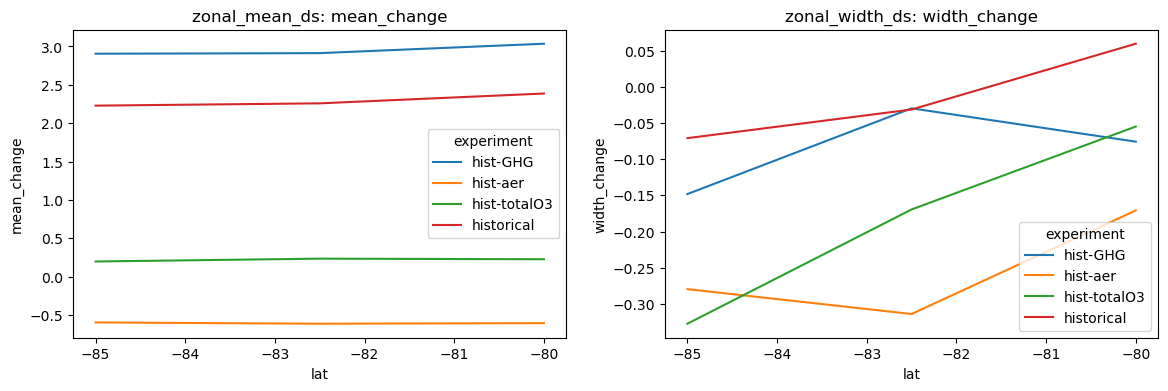

In [64]:
#(t): Quick look: DEMO_MODEL's zonal-mean change in the mean and in the width, one line per experiment
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
zonal_mean_ds['mean_change'].sel(**demo_sel).plot.line(x='lat', hue='experiment', ax=axes[0])
zonal_width_ds['width_change'].sel(**demo_sel).plot.line(x='lat', hue='experiment', ax=axes[1])
axes[0].set_title('zonal_mean_ds: mean_change')
axes[1].set_title('zonal_width_ds: width_change');

For the demonstration model and season: the zonal-mean change in the mean and in the width for each experiment, with dots where it is significant. The grey band in the width panel is the central 95% of the hist-nat trials, the changes natural variability gives on its own; a line outside it is significant.

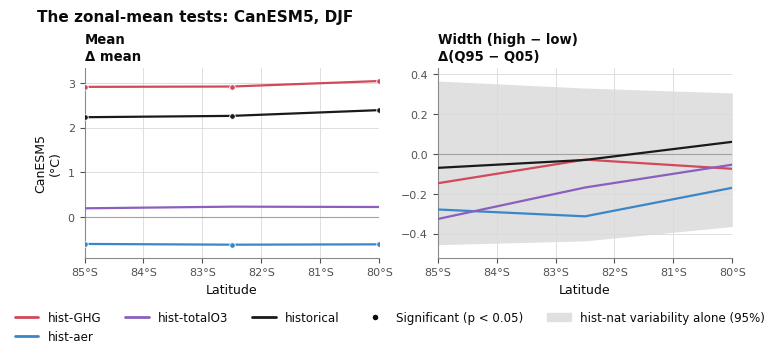

In [65]:
zonal_demo_ds = xr.merge([zonal_mean_ds.rename(pvalue='mean_pvalue'), zonal_width_ds], join='outer')
fig, axes = zp.zonal_change_grid(zonal_demo_ds, DEMO_POINT['season'], row_values=[DEMO_MODEL],
                                 columns=('mean_change', 'width_change'), units=var.units,
                                 title=f'The zonal-mean tests: {DEMO_MODEL}, {DEMO_POINT["season"]}')

## Saved results

Everything notebook 04 needs, and where it is:

In [66]:
pd.Series({name: str(paths.find(result_path(name))) for name in [
    'q_histnat_base', 'rolling_quantiles', 'smooth_quantiles', 'qrange_change', 'quantile_response', 'quantile_curve',
    'ttest', 'mean_block', 'signal', 'noise', 'sn', 'own_changes', 'mean_response', 'tails',
    'zonal_mean_test', 'zonal_width_test']}, name='path').to_frame()

,path
q_histnat_base,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
rolling_quantiles,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
smooth_quantiles,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
qrange_change,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
quantile_response,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
quantile_curve,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
ttest,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
mean_block,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
signal,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
noise,/work/scratch-pw4/aborow/ExtAnt/results/tas/sa...
